In [ ]:
! pip install pandas_datareader

import pandas as pd
import yfinance as yf
import requests
import io
from pandas_datareader import data as web
import datetime
import os


In [ ]:


def get_sp500_tickers():
    """
    Scrapes the current S&P 500 constituents from Wikipedia using a User-Agent
    to bypass 403 Forbidden errors, and formats tickers for yfinance.
    """
    print("Fetching S&P 500 constituents from Wikipedia...")

    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'


    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    # Get the webpage content
    response = requests.get(url, headers=headers)

    # Pass the raw HTML text to pandas
    tables = pd.read_html(response.text)
    sp500_df = tables[0]

    # Extract and clean the tickers
    raw_tickers = sp500_df['Symbol'].tolist()
    clean_tickers = [ticker.replace('.', '-') for ticker in raw_tickers]

    return clean_tickers

#  Execution
sp500_tickers = get_sp500_tickers()

print(f"\nSuccessfully loaded {len(sp500_tickers)} S&P 500 tickers.")
print("First 10 tickers as a sample:", sp500_tickers[:10])

# Test download
test_data = yf.download(sp500_tickers[:3], start="2015-01-01", end="2025-01-01")['Close']
print("\nSample Data Download Check:")
print(test_data.head())
print(test_data.tail())

Fetching S&P 500 constituents from Wikipedia...


/tmp/ipykernel_3733/3453748545.py:19: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)



Successfully loaded 503 S&P 500 tickers.
First 10 tickers as a sample: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


/tmp/ipykernel_3733/3453748545.py:35: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test_data = yf.download(sp500_tickers[:3], start="2015-01-01", end="2025-01-01")['Close']
[*********************100%***********************]  3 of 3 completed


Sample Data Download Check:
Ticker            ABT        AOS        MMM
Date                                       
2015-01-02  36.235119  23.357473  95.679245
2015-01-05  36.243206  22.948790  93.521385
2015-01-06  35.831608  22.761133  92.524124
2015-01-07  36.122139  22.927942  93.194824
2015-01-08  36.864594  23.524281  95.428467
Ticker             ABT        AOS         MMM
Date                                         
2024-12-24  112.058296  67.168541  127.372871
2024-12-26  112.556282  67.168541  128.174088
2024-12-27  112.282875  66.720047  127.197006
2024-12-30  110.144440  66.320274  126.171051
2024-12-31  110.447136  66.505539  126.131973


In [ ]:
#  Download ALL tickers
data = yf.download(
    sp500_tickers,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True,
    threads=True
)

#  Extract CLOSE only
close_prices = data["Close"]

print("Shape:", close_prices.shape)
print(close_prices.head())
print(close_prices.tail())

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1420088400, endDate = 1735707600")')


Shape: (2516, 503)
Ticker              A       AAPL       ABBV  ABNB        ABT       ACGL  \
Date                                                                      
2015-01-02  36.970360  24.214893  41.755478   NaN  36.235119  18.539352   
2015-01-05  36.277618  23.532719  40.969666   NaN  36.243195  18.428413   
2015-01-06  35.712502  23.534945  40.766872   NaN  35.831604  18.469618   
2015-01-07  36.186485  23.864944  42.414543   NaN  36.122128  18.577387   
2015-01-08  37.271156  24.781898  42.858147   NaN  36.864594  18.900694   

Ticker            ACN       ADBE        ADI        ADM  ...         WY  \
Date                                                    ...              
2015-01-02  74.252617  72.339996  44.216026  37.381660  ...  23.302099   
2015-01-05  72.998940  71.980003  43.411972  36.088181  ...  23.302099   
2015-01-06  72.472374  70.529999  42.392944  35.376770  ...  23.276283   
2015-01-07  73.993523  71.110001  42.838768  35.908535  ...  23.347263   
2015-01-08 

In [ ]:
# Remove dead tickers
sp500_clean_close = close_prices.dropna(axis=1, how='all')

# Keep tickers with at least 95% data
threshold = int(0.95 * len(sp500_clean_close))
sp500_clean_close = sp500_clean_close.dropna(axis=1, thresh=threshold)

# Fill small gaps
sp500_clean_close = sp500_clean_close.ffill()

# Drop any remaining NaN rows
sp500_clean_close = sp500_clean_close.dropna()

# Save
sp500_clean_close.to_csv("sp500_close_clean.csv")

print("Saved: sp500_close_clean.csv")

Saved: sp500_close_clean.csv


In [ ]:
sp500_clean_close

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2015-07-06,36.054958,28.134207,43.917850,40.560032,21.965755,82.227051,80.500000,51.273552,34.949215,63.846218,...,106.612198,20.832375,90.184296,23.568676,51.961014,31.695562,53.243805,96.676048,111.839996,44.396214
2015-07-07,36.448853,28.064983,44.136719,40.943279,22.032318,83.359024,80.589996,51.104218,34.985535,64.035797,...,106.227905,21.049036,96.669418,24.248404,52.175091,31.809212,52.785767,97.546951,112.320000,43.919212
2015-07-08,35.496185,27.368332,43.557331,40.160461,21.870667,82.463608,79.989998,49.943123,34.527691,63.214294,...,105.391479,20.720764,90.409988,24.119608,51.608456,31.101000,51.159164,95.920715,108.470001,42.635036
2015-07-09,35.651897,26.810110,43.756897,40.111538,21.750219,82.573425,80.470001,49.096485,34.222473,63.735615,...,105.820976,20.523798,91.330208,23.847727,51.375492,31.074759,51.670036,94.943192,108.440002,42.717590
2015-07-10,36.091599,27.526869,44.568050,40.714951,21.997452,83.443481,80.589996,49.596413,34.309666,64.391212,...,106.227905,20.543491,90.201630,24.005127,51.765831,30.943609,53.355389,94.916519,109.750000,43.075340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,134.457245,256.797211,172.530670,112.058289,92.669998,356.539642,447.940002,213.882050,48.364082,287.654846,...,310.595886,27.116615,87.733505,65.030983,101.953659,116.360298,131.828491,105.724747,395.440002,161.848892
2024-12-26,134.190506,257.612701,171.763855,112.556282,92.930000,355.356506,450.160004,213.852631,48.344978,288.402008,...,312.404205,27.030256,88.257271,65.002380,102.039902,116.675453,132.805008,105.675476,396.850006,162.654694
2024-12-27,133.904007,254.201385,170.623245,112.282875,92.339996,351.166351,446.480011,212.803284,48.316322,287.383148,...,310.871063,26.857540,87.634689,64.964233,102.030319,115.749687,132.053101,105.301056,389.070007,161.750626


# Ibovespa (B3)

In [ ]:
def get_bovespa_tickers():
    """
    Fetch all companies listed on B3 from Wikipedia
    and format tickers for Yahoo Finance (.SA suffix)
    """

    url = "https://en.wikipedia.org/wiki/List_of_companies_listed_on_B3"

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    # Request page
    response = requests.get(url, headers=headers)
    response.raise_for_status()

    # Read tables
    tables = pd.read_html(response.text)
    df = tables[0]   # first table contains tickers

    # Preview only
    print("Preview of first 20 rows:")
    print(df.head(20))

    # Confirm full dataset size
    print("\nFull dataframe shape:", df.shape)

    # Extract ALL tickers
    tickers = df["Ticker"].astype(str).str.strip() + ".SA"

    return tickers.tolist()



bovespa_tickers = get_bovespa_tickers()

print("\nTotal tickers loaded:", len(bovespa_tickers))
print("Sample:", bovespa_tickers[:10])

Preview of first 20 rows:
               Company  Ticker            Industry    Headquarters
0           Alpargatas   ALPA4            clothing       São Paulo
1                Ambev   ABEV3           beverages       São Paulo
2           Americanas   AMER3              retail  Rio de Janeiro
3                 Azul   AZUL4            airlines         Barueri
4                   B3   B3SA3      stock exchange       São Paulo
5      Banco do Brasil   BBAS3             banking        Brasília
6   BB Seguridade [pt]   BBSE3           insurance        Brasília
7             Bradesco   BBDC3             banking          Osasco
8             Bradesco   BBDC4             banking          Osasco
9     Banco Inter [pt]  BIDI11             banking  Belo Horizonte
10           Banco Pan   BPAN4             banking       São Paulo
11           Bradespar   BRAP4             holding       São Paulo
12             BRMalls   BRML3         real estate  Rio de Janeiro
13             Braskem   BRKM5      

/tmp/ipykernel_1740/822035306.py:18: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [ ]:
#  Download price data
data = yf.download(
    bovespa_tickers,
    start="2015-01-01",
    end="2025-01-01",
    group_by="ticker",
    auto_adjust=True,
    threads=True
)

#  Extract CLOSE only
close_prices = pd.DataFrame({
    ticker: data[ticker]["Close"]
    for ticker in bovespa_tickers
})

#  Preview
print(close_prices.head())
print("\nShape:", close_prices.shape)

[                       0%                       ]ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: EMBR3.SA"}}}
[*********************100%***********************]  88 of 88 completed
ERROR:yfinance:
22 Failed downloads:
ERROR:yfinance:['EMBR3.SA', 'SULA11.SA', 'CIEL3.SA', 'GOLL4.SA', 'BRFS3.SA', 'ELET6.SA', 'CPLE6.SA', 'BRML3.SA', 'PETZ3.SA', 'AZUL4.SA', 'ELET3.SA', 'ENBR3.SA', 'BIDI11.SA', 'BPAN4.SA', 'CRFB3.SA', 'CCRO3.SA', 'NTCO3.SA', 'JBSS3.SA', 'MRFG3.SA', 'SOMA3.SA', 'VIIA3.SA', 'LCAM3.SA']: YFTzMissingError('possibly delisted; no timezone found')


            ALPA4.SA   ABEV3.SA     AMER3.SA  AZUL4.SA  B3SA3.SA  BBAS3.SA  \
Date                                                                         
2015-01-02  3.787824   9.140122  2054.114502       NaN  2.080823  5.454774   
2015-01-05  3.684716   8.974662  1988.457886       NaN  2.023932  5.341587   
2015-01-06  3.652157   9.316989  1994.085693       NaN  2.043626  5.416242   
2015-01-07  3.608743   9.448214  1974.388672       NaN  2.124583  5.654665   
2015-01-08  3.663010  10.017530  1909.669922       NaN  2.096138  5.673930   

             BBSE3.SA  BBDC3.SA  BBDC4.SA  BIDI11.SA  ...  VIVT3.SA  TIMS3.SA  \
Date                                                  ...                       
2015-01-02  11.844791  7.082288  7.178619        NaN  ...  8.932437  6.708936   
2015-01-05  11.489644  6.994992  7.193431        NaN  ...  8.755301  6.548927   
2015-01-06  11.977487  7.181528  7.430067        NaN  ...  8.538013  6.537496   
2015-01-07  11.786250  7.498628  7.725346       

In [ ]:
#  Remove completely empty columns
bovespa_close_clean = close_prices.dropna(axis=1, how='all')

#  Keep tickers with at least 95% data
threshold = int(0.95 * len(bovespa_close_clean))
bovespa_close_clean = bovespa_close_clean.dropna(axis=1, thresh=threshold)

#  Forward-fill small gaps (optional but recommended)
bovespa_close_clean = bovespa_close_clean.fillna(method="ffill")

# Drop any remaining NaN rows
bovespa_close_clean = bovespa_close_clean.dropna()

# Confirm clean dataset
print("Final shape:", bovespa_close_clean.shape)
print("Any NaNs left:", bovespa_close_clean.isna().sum().sum())

# Save to CSV
bovespa_close_clean.to_csv("bovespa_close_clean.csv")

print("CSV file saved: bovespa_close_clean.csv")

/tmp/ipykernel_1740/2777249583.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bovespa_close_clean = bovespa_close_clean.fillna(method="ffill")


Final shape: (2425, 57)
Any NaNs left: 0
CSV file saved: bovespa_close_clean.csv


In [ ]:
bovespa_close_clean

,ALPA4.SA,ABEV3.SA,AMER3.SA,B3SA3.SA,BBAS3.SA,BBSE3.SA,BBDC3.SA,BBDC4.SA,BRAP4.SA,BRKM5.SA,...,SUZB3.SA,TAEE11.SA,VIVT3.SA,TIMS3.SA,TOTS3.SA,UGPA3.SA,USIM5.SA,VALE3.SA,YDUQ3.SA,WEGE3.SA
Date,,,,,,,,,,,,,,,,,,,,,
2015-04-02,5.545317,11.472985,2053.176514,2.630018,6.041723,13.811132,7.953846,7.790313,1.086459,7.422251,...,16.613937,6.853654,9.981431,6.006041,10.493685,10.777430,3.895919,8.444169,12.793512,4.997585
2015-04-06,5.675463,11.710355,2121.646973,2.605951,6.257853,14.420154,7.961352,7.866161,1.085436,7.630352,...,16.613937,6.843860,9.812171,5.891747,10.493685,10.895535,3.934879,8.505156,13.101466,5.009956
2015-04-07,5.924435,11.832088,1979.078369,2.540309,6.061372,13.943354,7.906324,7.909151,1.130449,7.674494,...,16.613937,6.853654,9.507995,5.948894,10.394149,10.736416,3.740083,8.913291,13.088077,5.031603
2015-04-08,5.997996,11.825999,2072.873535,2.621267,5.980328,13.542681,7.968858,7.906617,1.122265,7.838452,...,16.613937,6.853654,9.569321,5.914607,10.402684,10.859447,3.584246,8.796012,13.422810,5.025417
2015-04-09,5.743364,11.765138,2086.942871,2.621267,5.761743,13.602784,7.803778,7.765024,1.109988,7.605126,...,16.613937,6.840597,9.689522,5.914607,10.337277,10.870930,3.607622,8.819465,13.703987,4.960472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-20,5.577283,10.756968,6.630000,9.725599,22.725014,30.267456,9.379412,10.279414,14.211940,12.190000,...,58.355595,30.831747,22.986162,12.901879,26.968613,15.008157,5.430000,48.259750,7.971955,52.464855
2024-12-23,5.214464,10.748173,5.960000,9.716129,22.574018,30.234318,9.231500,10.095857,14.110787,11.810000,...,59.941238,29.878283,22.240786,12.815866,27.105858,14.816681,5.240000,48.462967,7.715090,51.310528
2024-12-26,5.383216,10.677809,5.200000,9.782419,22.838263,30.217745,9.335907,10.174525,14.093926,11.790000,...,60.626392,30.107481,22.416706,12.578080,26.772547,14.488434,5.290000,48.604336,7.559137,51.707840


#EURO STOXX

In [ ]:
def get_eurostoxx_tickers():
    url = "https://en.wikipedia.org/wiki/EURO_STOXX_50"
    headers = {"User-Agent": "Mozilla/5.0"}

    response = requests.get(url, headers=headers)
    tables = pd.read_html(io.StringIO(response.text))

    df = None
    for t in tables:
        if "Ticker" in t.columns or "Symbol" in t.columns:
            df = t
            break

    col = "Ticker" if "Ticker" in df.columns else "Symbol"
    tickers = df[col].astype(str).str.strip().tolist()

    return tickers




In [ ]:
# Get tickers
euro_tickers = get_eurostoxx_tickers()

# Download ALL data
data = yf.download(
    euro_tickers,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True,
    threads=True
)

# Extract CLOSE
close_prices = data["Close"]

#  Clean
eurostoxx50_close_clean = close_prices.dropna(axis=1, how="all")
threshold = int(0.95 * len(eurostoxx50_close_clean))
eurostoxx50_close_clean = eurostoxx50_close_clean.dropna(axis=1, thresh=threshold)
eurostoxx50_close_clean = eurostoxx50_close_clean.ffill().dropna()

#  Save
eurostoxx50_close_clean.to_csv("eurostoxx50_close_clean.csv")

print("Final shape:", eurostoxx50_close_clean.shape)
print("Saved: eurostoxx50_close_clean.csv")

[*********************100%***********************]  50 of 50 completed


Final shape: (2563, 46)
Saved: eurostoxx50_close_clean.csv


In [ ]:
eurostoxx50_close_clean

Ticker,ABI.BR,AD.AS,ADS.DE,AI.PA,AIR.PA,ALV.DE,ARGX.BR,ASML.AS,BAS.DE,BAYN.DE,...,SAN.MC,SAN.PA,SAP.DE,SGO.PA,SIE.DE,SU.PA,TTE.PA,UCG.MI,VOW.DE,WKL.AS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,73.007408,10.038220,50.100460,53.456779,35.344646,80.519257,7.520000,79.890190,39.671360,81.965034,...,4.330419,49.150780,49.115639,26.552038,57.480679,46.460812,21.952240,19.262169,109.375015,20.443453
2015-01-05,71.376289,9.805331,48.617516,51.801414,35.451042,78.546043,7.700000,78.420204,37.974976,79.208694,...,4.132714,47.736977,47.497002,25.408106,55.745716,44.438084,20.638460,17.986294,106.055969,20.184576
2015-01-06,70.667084,9.966300,48.493195,51.369118,36.272423,78.634392,7.700000,75.892525,37.963593,80.115395,...,4.060653,47.893337,46.426338,25.004141,55.696667,44.500069,20.607479,17.738207,106.916473,20.225023
2015-01-07,72.384911,10.038220,48.981590,51.601078,37.217213,79.370667,7.800000,76.143509,38.214062,80.115395,...,4.086520,48.401539,46.257729,24.936184,56.052250,44.779072,21.074663,17.564547,107.438919,20.176491
2015-01-08,75.970253,10.277960,50.597736,53.773090,38.485451,81.461693,8.400000,79.047630,39.773827,84.467499,...,4.222634,50.440788,47.269375,25.944204,57.885288,46.623547,21.887709,18.411587,111.587730,20.645702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,47.291023,30.083628,232.754776,151.512863,150.516586,282.033844,595.400024,676.297607,40.193909,18.799616,...,4.204054,87.908089,234.232895,83.583527,180.815414,234.881546,47.562813,35.762478,83.999947,156.707306
2024-12-24,47.457642,30.170547,232.754776,151.611099,150.320984,282.033844,604.599976,680.946045,40.193909,18.799616,...,4.193863,87.879356,234.232895,83.740051,180.815414,235.569183,47.709583,35.762478,83.999947,156.707306
2024-12-27,47.751682,30.305754,233.844742,153.143509,151.885818,282.896606,605.000000,677.385559,40.549900,19.189741,...,4.258892,89.344810,237.354675,84.327011,181.408646,236.797134,48.388397,36.364689,85.784180,158.181046


# FTSE100

In [ ]:
def get_ftse100_tickers():
    url = "https://en.wikipedia.org/wiki/FTSE_100_Index"
    headers = {"User-Agent": "Mozilla/5.0"}

    response = requests.get(url, headers=headers)
    tables = pd.read_html(io.StringIO(response.text))

    df = None
    for t in tables:
        if "EPIC" in t.columns or "Ticker" in t.columns:
            df = t
            break

    col = "EPIC" if "EPIC" in df.columns else "Ticker"
    tickers = df[col].astype(str).str.strip() + ".L"

    return tickers.tolist()




In [ ]:
# Get tickers
ftse_tickers = get_ftse100_tickers()

#  Download ALL data
data = yf.download(
    ftse_tickers,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True,
    threads=True
)

#  Extract CLOSE only
close_prices = data["Close"]

# Clean dataset
ftse100_close_clean = close_prices.dropna(axis=1, how="all")
threshold = int(0.95 * len(ftse100_close_clean))
ftse100_close_clean = ftse100_close_clean.dropna(axis=1, thresh=threshold)
ftse100_close_clean = ftse100_close_clean.ffill().dropna()

#  Save to CSV
ftse100_close_clean.to_csv("ftse100_close_clean.csv")

print("Final shape:", ftse100_close_clean.shape)
print("Saved: ftse100_close_clean.csv")

[*********************100%***********************]  100 of 100 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['BT.A.L']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['MTLN.L']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1420070400, endDate = 1735689600")')


Final shape: (2472, 91)
Saved: ftse100_close_clean.csv


In [ ]:
ftse100_close_clean

Ticker,AAL.L,ABF.L,ADM.L,ALW.L,ANTO.L,AUTO.L,AV.L,AZN.L,BA.L,BAB.L,...,SSE.L,STAN.L,STJ.L,SVT.L,TSCO.L,ULVR.L,UU.L,VOD.L,WEIR.L,WTB.L
Date,,,,,,,,,,,,,,,,,,,,,
2015-03-19,1016.359192,3054.310791,1507.786499,522.266541,693.019714,255.703400,554.159485,4769.775391,544.876099,983.951233,...,1522.799072,997.449280,962.662292,2047.781494,306.002594,3086.346436,946.343750,224.325821,1775.169312,4650.340332
2015-03-20,1069.314941,3031.361572,1530.632202,522.266541,712.464355,265.192383,558.075928,4831.073730,543.382019,993.431580,...,1544.666870,1017.388672,974.614563,2058.731689,308.586304,3089.541504,944.353516,226.659439,1837.035889,4654.625000
2015-03-23,1082.432129,3004.420898,1546.524292,518.276123,724.928711,264.692993,552.690796,4824.095215,537.903381,990.437805,...,1558.583252,1083.379150,970.630676,2072.669434,310.791748,3094.868896,953.309692,226.063614,1797.121460,4586.049805
2015-03-24,1062.513306,2918.608154,1559.437378,515.781799,721.937195,264.692993,559.544373,4816.122070,540.393433,993.930359,...,1546.655151,1063.439697,986.068909,2087.602539,307.073792,3096.999512,951.817078,225.368469,1788.140991,4573.191895
2015-03-25,1073.201782,2904.638916,1534.605225,511.791382,726.424500,260.447876,552.201233,4745.854492,539.397339,980.458618,...,1553.613037,1047.772583,975.112671,2080.634033,301.654572,3068.235596,953.309692,222.687332,1764.192627,4547.475586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,2288.139160,2047.390259,2617.195801,1245.653687,1621.225464,784.046509,461.896759,10418.711914,1157.279663,494.966309,...,1603.773071,980.185974,860.751831,2504.884766,365.866760,4869.264648,1043.536621,66.448746,2181.623779,2922.033203
2024-12-24,2335.706299,2042.391724,2622.192383,1249.652466,1617.726196,793.644592,462.595978,10432.707031,1158.279419,499.365997,...,1604.772583,990.179688,864.750671,2535.871094,368.365845,4877.816895,1043.036865,67.728149,2197.621338,2958.021484
2024-12-27,2296.966064,2043.391479,2616.196533,1235.656250,1618.725952,791.245117,465.492828,10456.700195,1155.280029,498.766052,...,1606.271973,981.984863,865.250549,2516.879639,366.766449,4892.782227,1050.533447,67.308334,2187.623047,2909.037598


# FTSE/JSE Top 40

In [ ]:
def get_jse40_tickers_custom():
    """
    Returns the specific JSE Top 40 list provided for the project.
    """
    jse_custom_list = [
        "ABG.JO", "AGL.JO", "ANG.JO", "ANH.JO", "APN.JO", "BHG.JO", "BID.JO",
        "BVT.JO", "BTI.JO", "CPI.JO", "CLS.JO", "DSY.JO", "EXX.JO", "FSR.JO",
        "GLN.JO", "GFI.JO", "GRT.JO", "IMP.JO", "INL.JO", "INP.JO", "MNP.JO",
        "MRP.JO", "MTN.JO", "MCG.JO", "NPN.JO", "NED.JO", "NRP.JO", "NPH.JO",
        "OMU.JO", "PRX.JO", "RNI.JO", "REM.JO", "RMH.JO", "SLM.JO", "SOL.JO",
        "SHP.JO", "SBK.JO","SSW.JO", "VOD.JO", "WHL.JO"
    ]
    return jse_custom_list

# Execution
jse_tickers = get_jse40_tickers_custom()
print(f"Loaded {len(jse_tickers)} JSE Top 40 tickers from your provided list.")

#  Preview: First 20 rows for the first 5 tickers
print("\nDownloading 1-month preview for JSE 40...")
# Standardizing on 'Adj Close' for return and correlation analysis
data = yf.download(jse_tickers[:5], period="2mo", interval="1d")['Close']

# Using forward fill to handle any non-synchronous holidays/missing data
data_cleaned = data.ffill().dropna()

print("\nFirst 20 Rows of Adjusted Close Prices:")
print(data_cleaned.head(20))

/tmp/ipykernel_1740/357678247.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(jse_tickers[:5], period="2mo", interval="1d")['Close']
[                       0%                       ]

Loaded 40 JSE Top 40 tickers from your provided list.



[*********************100%***********************]  5 of 5 completed


First 20 Rows of Adjusted Close Prices:
Ticker       ABG.JO        AGL.JO         ANG.JO    ANH.JO   APN.JO
Date                                                               
2026-02-09  25654.0  75982.835938  167599.359375  120756.0  10985.0
2026-02-10  25969.0  77822.828125  170080.343750  119868.0  10925.0
2026-02-11  26100.0  79792.820312  175826.281250  121638.0  10905.0
2026-02-12  26557.0  79260.828125  176498.281250  127363.0  11759.0
2026-02-13  26175.0  77759.828125  171098.328125  127171.0  12515.0
2026-02-16  26553.0  77119.828125  172098.312500  125912.0  12300.0
2026-02-17  26308.0  74761.835938  165499.375000  127217.0  12400.0
2026-02-18  27034.0  78674.828125  172445.312500  126758.0  12500.0
2026-02-19  26995.0  76874.828125  171153.328125  126825.0  12661.0
2026-02-20  26843.0  78563.828125  179100.250000  126074.0  12574.0
2026-02-23  26911.0  79581.828125  192178.125000  126654.0  12825.0
2026-02-24  27159.0  78943.828125  191809.125000  128185.0  12988.0
2026-02

In [ ]:
import pandas as pd
import yfinance as yf

def get_jse40_tickers_custom():
    return [
        "ABG.JO", "AGL.JO", "ANG.JO", "ANH.JO", "APN.JO", "BHG.JO", "BID.JO",
        "BVT.JO", "BTI.JO", "CPI.JO", "CLS.JO", "DSY.JO", "EXX.JO", "FSR.JO",
        "GLN.JO", "GFI.JO", "GRT.JO", "IMP.JO", "INL.JO", "INP.JO", "MNP.JO",
        "MRP.JO", "MTN.JO", "MCG.JO", "NPN.JO", "NED.JO", "NRP.JO", "NPH.JO",
        "OMU.JO", "PRX.JO", "RNI.JO", "REM.JO", "RMH.JO", "SLM.JO", "SOL.JO",
        "SHP.JO", "SBK.JO","SSW.JO", "VOD.JO", "WHL.JO"
    ]



In [ ]:
#  Get tickers
jse_tickers = get_jse40_tickers_custom()

#  Download ALL tickers
data = yf.download(
    jse_tickers,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True,
    threads=True
)

#  Extract CLOSE only
close_prices = data["Close"]

#  Clean dataset
jse40_close_clean = close_prices.dropna(axis=1, how="all")
threshold = int(0.95 * len(jse40_close_clean))
jse40_close_clean = jse40_close_clean.dropna(axis=1, thresh=threshold)
jse40_close_clean = jse40_close_clean.ffill().dropna()

# Save CSV
jse40_close_clean.to_csv("jse40_close_clean.csv")

print("Final shape:", jse40_close_clean.shape)
print("Saved: jse40_close_clean.csv")

[*********************100%***********************]  40 of 40 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['MCG.JO']: YFTzMissingError('possibly delisted; no timezone found')


Final shape: (2527, 31)
Saved: jse40_close_clean.csv


In [ ]:
jse40_close_clean

Ticker,ABG.JO,AGL.JO,ANG.JO,APN.JO,BTI.JO,BVT.JO,CLS.JO,CPI.JO,DSY.JO,EXX.JO,...,NPN.JO,NRP.JO,REM.JO,RMH.JO,SBK.JO,SHP.JO,SLM.JO,SOL.JO,VOD.JO,WHL.JO
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,18069.876953,20987.373047,10160.758789,40544.191406,62857.531250,8194.288086,8079.852539,33934.539062,10832.157227,10222.407227,...,19031.968750,10891.021484,17816.187500,92.604851,14258.891602,16774.007812,6960.457031,42979.675781,12761.456055,7678.583008
2015-01-02,17860.384766,20828.505859,9832.056641,40574.148438,62361.234375,8124.987305,8055.912598,33884.632812,10637.681641,10384.383789,...,19209.085938,10910.129883,17466.167969,91.194298,14137.649414,16824.859375,6892.841309,42978.675781,12550.800781,7593.928223
2015-01-05,17250.775391,19736.880859,10264.662109,40294.535156,61015.558594,7757.987305,7841.447754,32395.509766,10418.904297,10041.660156,...,19003.955078,10986.557617,16786.455078,86.718117,13441.995117,16131.922852,6517.971191,40387.992188,12085.771484,7310.090332
2015-01-06,17700.537109,20135.519531,10962.029297,40596.117188,60669.445312,7884.726074,8031.972168,32329.634766,10793.263672,10267.837891,...,19960.384766,10977.005859,17015.833984,89.323265,13972.679688,16829.839844,6622.377441,39937.253906,12266.615234,7589.944336
2015-01-07,18069.876953,20035.128906,11093.909180,40753.898438,60627.675781,7991.238770,8140.701172,32936.468750,10784.511719,10193.760742,...,20726.244141,11105.977539,17459.148438,90.964066,14294.666992,17247.595703,6652.208496,40228.445312,12669.046875,7718.418457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,19086.484375,52978.808594,43175.347656,17416.205078,66804.578125,27182.314453,38204.519531,317651.250000,19743.417969,15813.506836,...,85817.070312,13978.162109,15506.060547,44.000000,22520.869141,30158.111328,8699.619141,8322.000000,10103.069336,6206.391113
2024-12-24,19215.371094,53523.289062,43755.328125,17196.253906,66840.554688,27383.191406,37941.628906,316639.437500,19806.408203,15941.374023,...,85495.882812,13939.165039,15585.036133,45.000000,22532.861328,30217.087891,8763.549805,8305.000000,10162.040039,6278.349121
2024-12-27,19004.554688,54116.910156,43240.343750,16996.296875,68025.593750,26860.511719,37737.710938,316550.437500,19622.441406,15694.630859,...,84937.906250,13905.166992,15472.071289,45.000000,22306.015625,29826.242188,8628.694336,8265.000000,10230.006836,6199.394531


# Nikkei225

In [ ]:
# Full list of Nikkei 225 tickers
nikkei_tickers = [
    "6857.T", "8267.T", "5201.T", "2802.T", "6770.T", "6113.T", "9202.T",
    "8304.T", "2502.T", "3407.T", "4503.T", "7832.T", "5108.T", "7751.T",
    "6952.T", "9022.T", "9502.T", "4519.T", "7762.T", "1721.T", "7186.T",
    "8253.T", "4751.T", "7912.T", "8750.T", "4568.T", "6367.T", "1925.T",
    "8601.T", "2432.T", "4061.T", "6902.T", "4324.T", "4631.T", "5714.T",
    "9020.T", "6361.T", "4523.T", "5020.T", "6954.T", "9983.T", "6504.T",
    "4901.T", "5803.T", "6702.T", "8354.T", "5801.T", "6674.T", "1808.T",
    "7205.T", "6305.T", "7004.T", "6501.T", "7267.T", "7741.T", "5019.T",
    "7013.T", "1605.T", "3099.T", "7202.T", "8001.T", "3086.T", "9201.T",
    "8697.T", "6178.T", "2914.T", "5411.T", "1963.T", "6473.T", "1812.T",
    "4452.T", "7012.T", "9107.T", "9433.T", "9008.T", "9009.T", "6861.T",
    "2801.T", "2503.T", "5406.T", "6301.T", "9766.T", "4902.T", "6326.T",
    "3405.T", "6971.T", "4151.T", "6920.T", "4689.T", "2413.T", "8002.T",
    "8252.T", "7261.T", "2269.T", "4385.T", "6479.T", "4188.T", "8058.T",
    "6503.T", "8802.T", "7011.T", "9301.T", "5711.T", "7211.T", "8306.T",
    "8031.T", "4183.T", "8801.T", "5706.T", "9104.T", "8411.T", "8725.T",
    "6981.T", "6701.T", "3659.T", "5333.T", "2282.T", "2871.T", "6594.T",
    "7731.T", "7974.T", "5214.T", "9147.T", "3863.T", "5401.T", "9432.T",
    "9101.T", "4021.T", "7201.T", "2002.T", "1332.T", "9843.T", "6988.T",
    "8604.T", "6471.T", "6472.T", "9613.T", "1802.T", "9007.T", "3861.T",
    "6103.T", "7733.T", "6645.T", "4661.T", "8591.T", "9532.T", "4578.T",
    "5541.T", "6752.T", "4755.T", "6098.T", "6723.T", "8308.T", "4004.T",
    "7752.T", "2501.T", "7735.T", "9735.T", "6724.T", "1928.T", "3382.T",
    "6753.T", "1803.T", "4063.T", "4507.T", "4911.T", "5831.T", "6273.T",
    "9434.T", "9984.T", "2768.T", "8630.T", "6758.T", "7270.T", "3436.T",
    "4005.T", "8053.T", "5802.T", "6302.T", "5713.T", "8316.T", "8309.T",
    "5232.T", "4506.T", "8830.T", "7269.T", "8795.T", "5233.T", "1801.T",
    "6976.T", "2531.T", "8233.T", "4502.T", "6762.T", "3401.T", "4543.T",
    "8331.T", "5631.T", "9503.T", "5101.T", "9001.T", "9602.T", "5301.T",
    "8766.T", "4043.T", "9501.T", "8035.T", "9531.T", "8804.T", "9005.T",
    "3289.T", "7911.T", "3402.T", "4042.T", "5332.T", "7203.T", "8015.T",
    "4704.T", "4208.T", "9021.T", "7951.T", "7272.T", "9064.T", "6506.T",
    "6841.T"
]

print(f"Downloading {len(nikkei_tickers)} Nikkei 225 tickers...")

In [ ]:
# Download all historical Close prices
data = yf.download(
    nikkei_tickers,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True,
    threads=True
)["Close"]

# Drop completely failed tickers
nikkei225_close_clean = data.dropna(axis=1, how="all")

# Keep those with at least 95% of data
threshold = int(0.95 * len(nikkei225_close_clean))
nikkei225_close_clean = nikkei225_close_clean.dropna(axis=1, thresh=threshold)

# Fill small remaining gaps and drop any rows still with NaN
nikkei225_close_clean = nikkei225_close_clean.ffill().dropna()

# Save just Close to CSV
nikkei225_close_clean.to_csv("nikkei225_close_clean.csv")

print("Final shape:", nikkei225_close_clean.shape)
print("CSV saved: nikkei225_close_clean.csv")

[*********************100%***********************]  225 of 225 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['9613.T']: YFTzMissingError('possibly delisted; no timezone found')


Final shape: (2466, 218)
CSV saved: nikkei225_close_clean.csv


In [ ]:
nikkei225_close_clean

Ticker,1332.T,1605.T,1721.T,1801.T,1802.T,1803.T,1808.T,1812.T,1925.T,1928.T,...,9502.T,9503.T,9531.T,9532.T,9602.T,9735.T,9766.T,9843.T,9983.T,9984.T
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,297.138092,918.474731,1202.272583,2508.540527,546.366272,602.502808,610.771362,696.503540,1564.102173,1011.590820,...,1013.968689,836.325623,2515.514893,1682.719482,456.831177,2767.794189,1908.208984,1195.168579,13264.051758,833.326233
2015-01-06,289.171844,865.164307,1164.907715,2446.375732,533.057373,585.664917,595.612488,678.248596,1513.470459,990.189819,...,984.750977,806.987000,2444.738037,1626.113159,441.754211,2672.408203,1845.574829,1185.989014,13020.232422,815.637939
2015-01-07,293.154999,856.104980,1156.115967,2479.286377,533.057373,582.004395,593.717773,661.397583,1531.259644,999.453186,...,976.093933,802.278381,2425.186523,1615.546387,439.241425,2650.987305,1795.810181,1189.660645,13071.406250,822.271057
2015-01-08,290.765137,861.679565,1158.313843,2508.540527,540.762512,586.397034,600.033936,658.589233,1555.207031,1003.286255,...,986.193604,802.278381,2466.245361,1628.377075,447.114929,2687.766846,1811.254028,1189.660645,13366.396484,831.115051
2015-01-09,291.561707,860.983154,1151.719971,2537.795410,542.863892,582.004395,608.876465,655.780762,1538.786377,990.829041,...,993.047241,795.034363,2477.194092,1647.623535,445.439636,2692.617676,1763.205566,1202.512085,13473.255859,838.330139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,847.298096,1851.629517,3095.875732,6258.055176,1952.853516,1188.819336,1903.833008,2698.487061,4541.093262,3415.871338,...,1548.149170,1638.340332,4285.064941,3243.231201,1179.686523,5171.701172,14695.144531,3640.086670,52098.199219,2190.589111
2024-12-25,845.479065,1866.652954,3045.264404,6199.693848,1962.379517,1184.496338,1906.198608,2692.744873,4557.274414,3461.879883,...,1550.055664,1624.504639,4259.709961,3241.303467,1184.809937,5136.658691,14360.156250,3627.300537,52236.156250,2218.440674
2024-12-26,854.382935,1866.652954,3079.641602,6271.449219,1983.337036,1186.898071,1926.542725,2742.512939,4610.575684,3515.399414,...,1554.345581,1638.340332,4267.511719,3281.783691,1190.312500,5210.637695,14645.880859,3598.777832,52472.652344,2265.191895


# ASX50

In [ ]:
# Full list of ASX 50 tickers with .AX suffix
asx50_tickers = [
    "CBA.AX","BHP.AX","CSL.AX","NAB.AX","WBC.AX","ANZ.AX","MQG.AX","WES.AX",
    "GMG.AX","WDS.AX","RIO.AX","TCL.AX","WOW.AX","ALL.AX","FMG.AX","STO.AX",
    "BXB.AX","COL.AX","TLS.AX","QBE.AX","ORG.AX","APA.AX","SCG.AX","SHL.AX",
    "S32.AX","IAG.AX","CPU.AX","JHX.AX","NST.AX","RMD.AX","MIN.AX","ALD.AX",
    "BSL.AX","ASX.AX","REA.AX","XRO.AX","WTC.AX","SEK.AX","CAR.AX","QAN.AX",
    "AZJ.AX","LYC.AX","IGO.AX","ILU.AX","ORI.AX","TWE.AX","EDV.AX","TLC.AX",
    "SVW.AX","NWS.AX"
]

print(f"Downloading {len(asx50_tickers)} ASX 50 tickers...")



In [ ]:
# Download all historical Close prices
data = yf.download(
    asx50_tickers,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=True,
    threads=True
)["Close"]

# Drop completely failed tickers
asx50_close_clean = data.dropna(axis=1, how="all")

# Keep those with at least 95% of data
threshold = int(0.95 * len(asx50_close_clean))
asx50_close_clean = asx50_close_clean.dropna(axis=1, thresh=threshold)

# Fill small remaining gaps and drop any rows still with NaN
asx50_close_clean = asx50_close_clean.ffill().dropna()

# Save just Close to CSV
asx50_close_clean.to_csv("asx50_close_clean.csv")

print("Final shape:", asx50_close_clean.shape)
print("CSV saved: asx50_close_clean.csv")

[*********************100%***********************]  50 of 50 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SVW.AX']: YFTzMissingError('possibly delisted; no timezone found')


Final shape: (2439, 45)
CSV saved: asx50_close_clean.csv


In [ ]:
asx50_close_clean

Ticker,ALD.AX,ALL.AX,ANZ.AX,APA.AX,ASX.AX,AZJ.AX,BHP.AX,BSL.AX,BXB.AX,CAR.AX,...,SHL.AX,STO.AX,TCL.AX,TLS.AX,TWE.AX,WBC.AX,WDS.AX,WES.AX,WOW.AX,XRO.AX
Date,,,,,,,,,,,,,,,,,,,,,
2015-05-18,21.178694,6.620045,17.820688,4.916660,28.254824,2.858771,13.112219,2.731085,7.979172,7.036678,...,13.333454,5.126574,6.233136,3.528338,3.928908,18.179831,18.200768,18.005972,16.588629,18.820000
2015-05-19,21.307205,6.560710,17.666115,4.883364,27.738789,2.853241,12.894625,2.683725,7.913590,7.043709,...,13.305837,5.057803,6.183471,3.499792,3.899256,18.213682,18.079708,17.686310,16.157383,18.719999
2015-05-20,21.255806,6.569186,17.605387,4.983252,27.785702,2.853241,12.542122,2.604792,7.950023,7.205391,...,13.326552,4.863993,6.344887,3.499792,3.928908,18.202400,18.069178,17.573019,16.186134,18.680000
2015-05-21,21.686317,6.713284,17.787571,4.961055,27.745493,2.869830,12.724899,2.620579,8.139484,7.310835,...,13.651083,4.945268,6.394553,3.528338,3.943736,18.422457,18.353397,17.544689,16.306885,18.879999
2015-05-22,21.686317,6.679378,17.693714,4.927760,27.839312,2.925126,12.729256,2.628472,8.212356,7.310835,...,13.644178,5.057803,6.363510,3.539757,3.891843,18.371668,18.790262,17.532553,16.203382,19.280001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,26.148977,67.698616,27.193680,6.516030,62.232319,2.992198,37.538471,17.938866,18.467556,36.379078,...,25.759813,6.031975,12.862996,3.776196,10.956875,30.914492,21.782537,69.210365,29.144773,168.169998
2024-12-24,26.564348,67.708458,27.326794,6.543067,62.649799,3.001433,37.378532,17.837358,18.438776,36.379078,...,25.900784,6.078518,12.788482,3.794984,10.995118,31.048529,21.982794,68.959854,29.163965,168.660004
2024-12-27,26.564348,68.397652,27.402861,6.498005,62.830078,3.010668,37.416164,17.735853,18.457962,36.292507,...,25.788010,6.097136,12.872311,3.785590,11.033362,31.268730,22.064720,69.913750,29.279123,168.919998


# Macro indicators

In [ ]:
#  Set FRED API Key
os.environ["FRED_API_KEY"] = "6b71c3f6aa35c39d64f65e701ee0aaa1"

def get_macro_indicators_complete():
    """
    Downloads macro indicators:
      - Commodities/FX/VIX/crypto from Yahoo Finance
      - Interest rate yields from FRED
    Returns a cleaned, merged daily DataFrame.
    """

    #  Yahoo Finance tickers
    yf_map = {
        'Gold': 'GC=F',
        'Oil_Crude': 'CL=F',
        'Bitcoin': 'BTC-USD',
        'VIX': '^VIX',
        'USD_EUR': 'EURUSD=X',
        'USD_JPY': 'JPYUSD=X',
        # US Treasury proxies
        'US_TBill_1Y': '^IRX',
        'US_TBill_10Y': '^TNX'
    }

    yf_tickers = list(yf_map.values())
    print(f"Downloading {len(yf_tickers)} series from Yahoo Finance...")

    # Download historical daily data
    yf_data = yf.download(yf_tickers, start="2015-01-01", end="2025-01-01")["Close"]

    # Rename for readability
    yf_data = yf_data.rename(columns={v: k for k, v in yf_map.items()})

    # Drop columns with no data
    yf_data = yf_data.dropna(axis=1, how="all")

    #  FRED tickers
    # 10‑year government bond yields from FRED
    fred_map = {
        'Japan_10Y_Yield': 'IRLTLT01JPM156N',   # Japan 10Y
        'UK_10Y_Gilt_Yield': 'IRLTLT01GBM156N', # UK 10Y
        'Germany_10Y_Bund_Yield': 'IRLTLT01DEM156N'  # Germany 10Y
    }

    start = "2015-01-01"
    end = "2025-01-01"

    print(f"Downloading {len(fred_map)} series from FRED...")

    fred_data = pd.DataFrame()
    for name, ticker in fred_map.items():
        try:
            s = web.DataReader(ticker, "fred", start, end)
            fred_data[name] = s[ticker]
        except Exception as e:
            print(f"FRED download failed for {name} ({ticker}):", e)

    #  Merge Yahoo + FRED
    macro_data = pd.concat([yf_data, fred_data], axis=1)

    # Forward fill small gaps and drop any remaining NaNs
    macro_data = macro_data.ffill().dropna()

    return macro_data

#  Run
macro_data = get_macro_indicators_complete()
print("\nMacro indicators loaded.")
print("Shape:", macro_data.shape)
print(macro_data.head(20))

# Optional: save to CSV
macro_data.to_csv("macro_indicators_2015_2025.csv")
print("\nSaved macro indicators to macro_indicators_2015_2025.csv")

/tmp/ipykernel_1740/1284122268.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf_data = yf.download(yf_tickers, start="2015-01-01", end="2025-01-01")["Close"]
[                       0%                       ]

[*********************100%***********************]  8 of 8 completed



Macro indicators loaded.
Shape: (3653, 11)
               Bitcoin  Oil_Crude   USD_EUR         Gold   USD_JPY  \
2015-01-02  315.032013  52.689999  1.208941  1186.000000  0.008342   
2015-01-03  281.082001  52.689999  1.208941  1186.000000  0.008342   
2015-01-04  264.195007  52.689999  1.208941  1186.000000  0.008342   
2015-01-05  274.473999  50.040001  1.194643  1203.900024  0.008303   
2015-01-06  286.188995  47.930000  1.193902  1219.300049  0.008373   
2015-01-07  294.337006  48.650002  1.187536  1210.599976  0.008427   
2015-01-08  283.348999  48.790001  1.183600  1208.400024  0.008383   
2015-01-09  290.407990  48.360001  1.179607  1216.000000  0.008348   
2015-01-10  274.795990  48.360001  1.179607  1216.000000  0.008348   
2015-01-11  265.660004  48.360001  1.179607  1216.000000  0.008348   
2015-01-12  267.795990  46.070000  1.187070  1232.699951  0.008459   
2015-01-13  225.860992  45.889999  1.183152  1234.300049  0.008451   
2015-01-14  178.102997  48.480000  1.177829  1

In [ ]:
macro_data

,Bitcoin,Oil_Crude,USD_EUR,Gold,USD_JPY,US_TBill_1Y,US_TBill_10Y,VIX,Japan_10Y_Yield,UK_10Y_Gilt_Yield,Germany_10Y_Bund_Yield
2015-01-02,315.032013,52.689999,1.208941,1186.000000,0.008342,0.015,2.123,17.790001,0.275,1.5890,0.390000
2015-01-03,281.082001,52.689999,1.208941,1186.000000,0.008342,0.015,2.123,17.790001,0.275,1.5890,0.390000
2015-01-04,264.195007,52.689999,1.208941,1186.000000,0.008342,0.015,2.123,17.790001,0.275,1.5890,0.390000
2015-01-05,274.473999,50.040001,1.194643,1203.900024,0.008303,0.003,2.039,19.920000,0.275,1.5890,0.390000
2015-01-06,286.188995,47.930000,1.193902,1219.300049,0.008373,0.020,1.963,21.120001,0.275,1.5890,0.390000
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-28,95163.929688,70.599998,1.042318,2617.199951,0.006339,4.178,4.619,15.950000,1.090,4.4345,2.178889
2024-12-29,93530.226562,70.599998,1.042318,2617.199951,0.006339,4.178,4.619,15.950000,1.090,4.4345,2.178889
2024-12-30,92643.210938,70.989998,1.042938,2606.100098,0.006334,4.182,4.545,17.400000,1.090,4.4345,2.178889
2024-12-31,93429.203125,71.720001,1.040615,2629.199951,0.006370,4.208,4.573,17.350000,1.090,4.4345,2.178889


# 📊 EDA — Isaac
**Capstone Project | Multi-Index Equity Universe**

**Indices Covered:** S&P 500 · Ibovespa · EURO STOXX 50 · FTSE 100 · JSE Top 40 · Nikkei 225 · ASX 50  
**Time Horizon:** 10 Years  
**Training/Validation:** 2015-01-01 → 2025-12-31  
**Testing:** 2026-01-01 → 2026-03-30  
**Splits:** 80:20 · 70:30 · 80:10:10 · Cross-Fold Validation · CPCV


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import KFold, TimeSeriesSplit
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# ─── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3d4d',
    'axes.labelcolor': '#e0e0e0',
    'axes.titlecolor': '#ffffff',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.color': '#a0a0a0',
    'ytick.color': '#a0a0a0',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'text.color': '#e0e0e0',
    'grid.color': '#2a2d3d',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#3a3d4d',
    'legend.labelcolor': '#e0e0e0',
    'savefig.facecolor': '#0f1117',
    'font.family': 'DejaVu Sans',
})

# ─── Color palette ────────────────────────────────────────────────────────────
INDEX_COLORS = {
    'SP500':     '#4fc3f7',
    'Ibovespa':  '#81c784',
    'EUROSTOXX': '#ffb74d',
    'FTSE100':   '#f06292',
    'JSE40':     '#ce93d8',
    'Nikkei225': '#ff8a65',
    'ASX50':     '#4dd0e1',
}

TRAIN_COLOR   = '#4fc3f7'
VAL_COLOR     = '#81c784'
TEST_COLOR    = '#ff8a65'

# ─── Date constants ───────────────────────────────────────────────────────────
FULL_START = '2015-01-01'
FULL_END   = '2025-12-31'
TEST_START = '2026-01-01'
TEST_END   = '2026-03-30'

print('✅ Configuration loaded.')

✅ Configuration loaded.


In [ ]:
# ─── Load CSVs ────────────────────────────────────────────────────────────────
# Adjust paths if your CSVs are in a sub-folder
CSV_MAP = {
    'SP500':     'sp500_close_clean.csv',
    'Ibovespa':  'bovespa_close_clean.csv',
    'EUROSTOXX': 'eurostoxx50_close_clean.csv',
    'FTSE100':   'ftse100_close_clean.csv',
    'JSE40':     'jse40_close_clean.csv',
    'Nikkei225': 'nikkei225_close_clean.csv',
    'ASX50':     'asx50_close_clean.csv',
}

index_data = {}
for name, path in CSV_MAP.items():
    try:
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        # Filter to training window only (keep test separate)
        df = df.loc[FULL_START:FULL_END]
        index_data[name] = df
        print(f'  ✅  {name:12s}  shape={df.shape}  '
              f'  {df.index[0].date()} → {df.index[-1].date()}')
    except FileNotFoundError:
        print(f'  ⚠️   {name}: file not found → {path}')

# Also load macro if available
try:
    macro_data = pd.read_csv('macro_indicators_clean.csv',
                             index_col=0, parse_dates=True)
    macro_data = macro_data.loc[FULL_START:FULL_END]
    print(f'  ✅  Macro       shape={macro_data.shape}')
except FileNotFoundError:
    macro_data = None
    print('  ⚠️   macro_indicators_clean.csv not found — macro section skipped')

  ✅  SP500         shape=(2390, 465)    2015-07-06 → 2024-12-31
  ✅  Ibovespa      shape=(2425, 57)    2015-04-02 → 2024-12-30
  ✅  EUROSTOXX     shape=(2563, 46)    2015-01-02 → 2024-12-31
  ✅  FTSE100       shape=(2472, 91)    2015-03-19 → 2024-12-31
  ✅  JSE40         shape=(2527, 31)    2015-01-01 → 2024-12-31
  ✅  Nikkei225     shape=(2466, 218)    2015-01-05 → 2024-12-30
  ✅  ASX50         shape=(2439, 45)    2015-05-18 → 2024-12-31
  ⚠️   macro_indicators_clean.csv not found — macro section skipped


In [ ]:
summary_rows = []
for name, df in index_data.items():
    pct_missing = df.isnull().mean().mean() * 100
    summary_rows.append({
        'Index': name,
        'Tickers': df.shape[1],
        'Trading Days': df.shape[0],
        'Start': df.index[0].date(),
        'End': df.index[-1].date(),
        'Missing %': f'{pct_missing:.2f}%',
        'Avg Price': f'{df.stack().mean():.2f}',
    })

summary_df = pd.DataFrame(summary_rows).set_index('Index')
display(summary_df.style
        .set_table_styles([{'selector': 'th', 'props': [('background-color','#1a1d27'),
                                                         ('color','#4fc3f7')]}])
        .background_gradient(subset=['Tickers','Trading Days'], cmap='Blues'))

,Tickers,Trading Days,Start,End,Missing %,Avg Price
Index,,,,,,
SP500,465,2390,2015-07-06,2024-12-31,0.00%,119.19
Ibovespa,57,2425,2015-04-02,2024-12-30,0.00%,63.69
EUROSTOXX,46,2563,2015-01-02,2024-12-31,0.00%,98.57
FTSE100,91,2472,2015-03-19,2024-12-31,0.00%,1671.43
JSE40,31,2527,2015-01-01,2024-12-31,0.00%,21649.17
Nikkei225,218,2466,2015-01-05,2024-12-30,0.00%,2430.92
ASX50,45,2439,2015-05-18,2024-12-31,0.00%,27.37


In [ ]:
def normalise_minmax(df):
    """Scale each column to [0, 1] independently."""
    return (df - df.min()) / (df.max() - df.min())

def normalise_zscore(df):
    """Zero mean, unit variance per column."""
    return (df - df.mean()) / df.std()

def normalise_base100(df):
    """Rebase so first valid value = 100."""
    first_valid = df.apply(lambda s: s.dropna().iloc[0] if not s.dropna().empty else np.nan)
    return (df / first_valid) * 100

norm_data = {}
for name, df in index_data.items():
    norm_data[name] = {
        'raw':     df,
        'minmax':  normalise_minmax(df),
        'zscore':  normalise_zscore(df),
        'base100': normalise_base100(df),
    }

print('✅ Normalisation complete for all 3 strategies.')

✅ Normalisation complete for all 3 strategies.


In [ ]:
def temporal_split(df, train_ratio=0.8, val_ratio=0.0, same_start=True):
    """
    Split a time-series DataFrame chronologically.
    Always starts from the same date (index[0]).

    Returns: (train, val, test)  — val is empty if val_ratio=0
    """
    assert same_start, 'All splits must share the same start date.'
    n = len(df)
    train_end = int(n * train_ratio)
    if val_ratio > 0:
        val_end = train_end + int(n * val_ratio)
        return df.iloc[:train_end], df.iloc[train_end:val_end], df.iloc[val_end:]
    else:
        return df.iloc[:train_end], pd.DataFrame(), df.iloc[train_end:]


# ─── Show splits for one representative index ─────────────────────────────────
demo_name = next(iter(index_data))  # first available
demo_df   = index_data[demo_name]

splits = {
    '80:20':      temporal_split(demo_df, 0.80, 0.00),
    '70:30':      temporal_split(demo_df, 0.70, 0.00),
    '80:10:10':   temporal_split(demo_df, 0.80, 0.10),
}

print(f'Split summary for {demo_name} ({len(demo_df)} days):')
print(f'{"Split":<12}  {"Train":^20}  {"Val":^20}  {"Test":^20}')
print('-' * 78)
for label, (tr, va, te) in splits.items():
    tr_rng = f'{tr.index[0].date()} → {tr.index[-1].date()}' if len(tr) else 'N/A'
    va_rng = f'{va.index[0].date()} → {va.index[-1].date()}' if len(va) else 'N/A'
    te_rng = f'{te.index[0].date()} → {te.index[-1].date()}' if len(te) else 'N/A'
    print(f'{label:<12}  {tr_rng:^20}  {va_rng:^20}  {te_rng:^20}')

Split summary for SP500 (2390 days):
Split                Train                  Val                   Test        
------------------------------------------------------------------------------
80:20         2015-07-06 → 2023-02-06          N/A           2023-02-07 → 2024-12-31
70:30         2015-07-06 → 2022-02-23          N/A           2022-02-24 → 2024-12-31
80:10:10      2015-07-06 → 2023-02-06  2023-02-07 → 2024-01-19  2024-01-22 → 2024-12-31


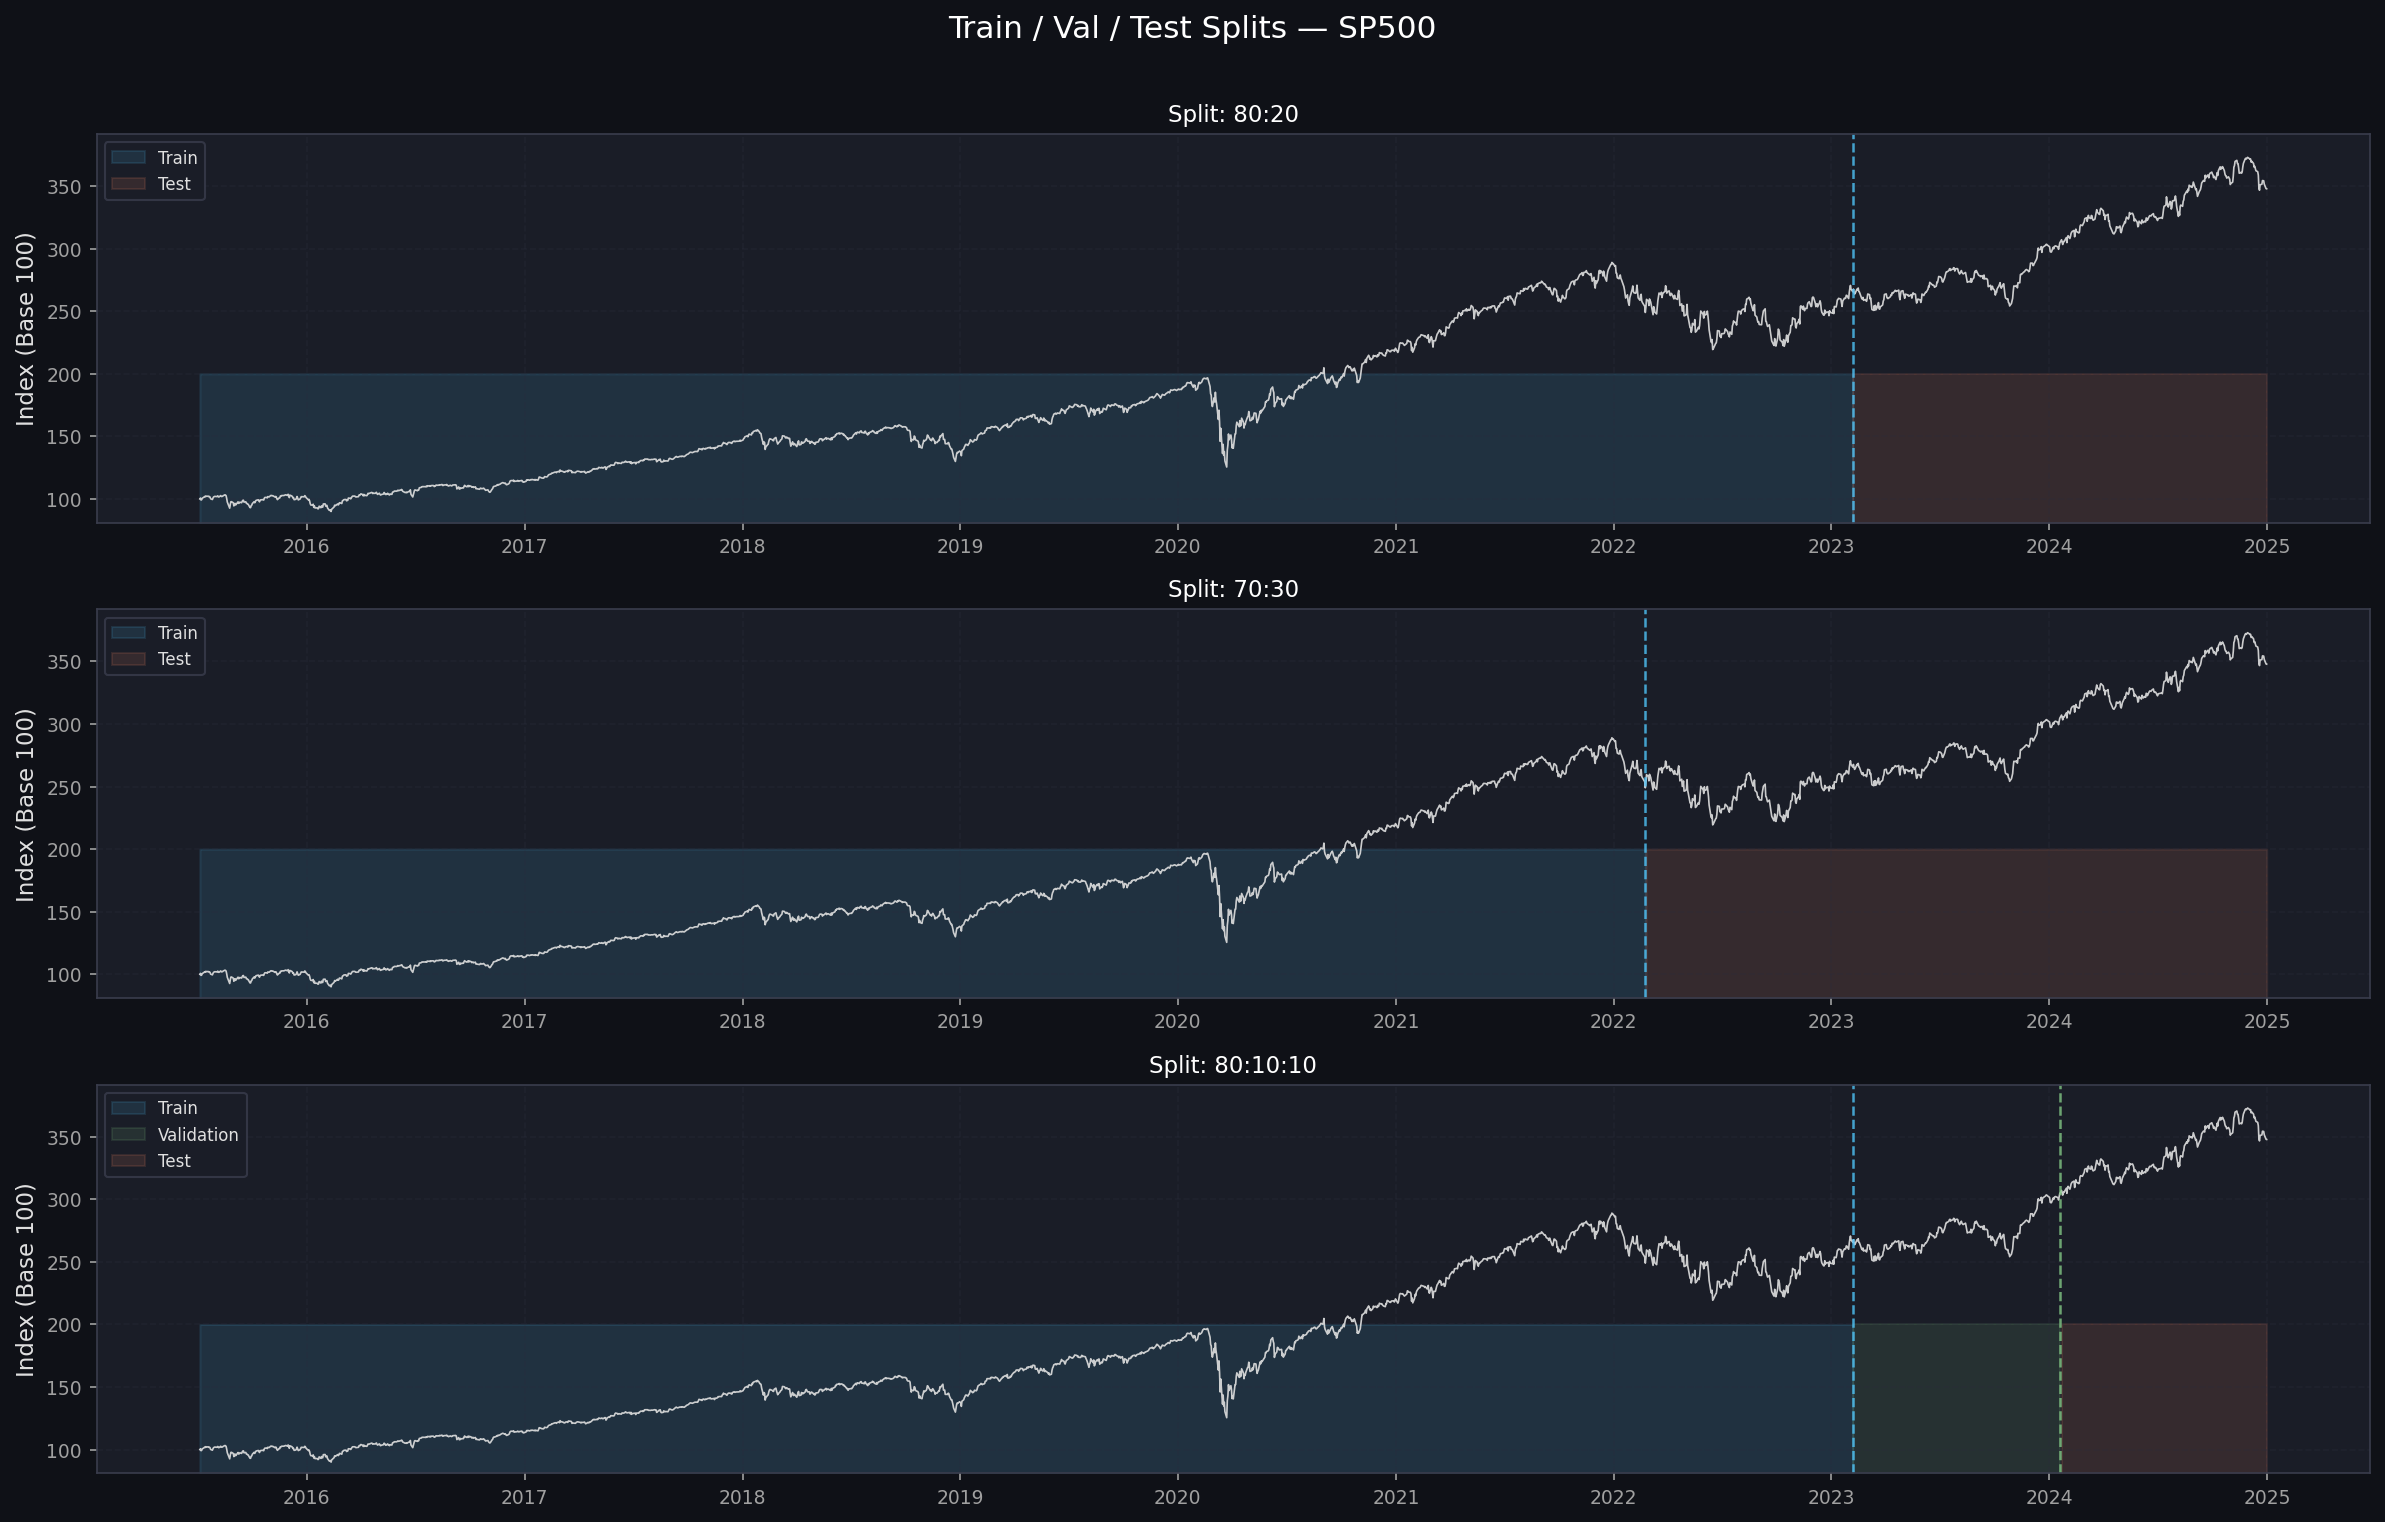

✅ Split visualisation saved.


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)
fig.suptitle(f'Train / Val / Test Splits — {demo_name}', fontsize=15, color='white', y=1.01)

# mean price across tickers as representative line
mean_price = demo_df.mean(axis=1)
norm_price = (mean_price / mean_price.iloc[0]) * 100  # base-100

configs = [
    ('80:20',    0.80, 0.00),
    ('70:30',    0.70, 0.00),
    ('80:10:10', 0.80, 0.10),
]

for ax, (label, tr_r, va_r) in zip(axes, configs):
    n = len(norm_price)
    tr_end  = int(n * tr_r)
    val_end = tr_end + int(n * va_r) if va_r > 0 else tr_end

    tr_idx  = norm_price.index[:tr_end]
    va_idx  = norm_price.index[tr_end:val_end]
    te_idx  = norm_price.index[val_end:]

    ax.fill_between(tr_idx,  0, 200, alpha=0.12, color=TRAIN_COLOR, label='Train')
    if len(va_idx):
        ax.fill_between(va_idx, 0, 200, alpha=0.12, color=VAL_COLOR, label='Validation')
    ax.fill_between(te_idx,  0, 200, alpha=0.12, color=TEST_COLOR, label='Test')

    ax.plot(norm_price, color='#e0e0e0', linewidth=0.8, alpha=0.9)

    # Vertical split lines
    ax.axvline(norm_price.index[tr_end-1],  color=TRAIN_COLOR, linestyle='--', linewidth=1.2, alpha=0.8)
    if len(va_idx):
        ax.axvline(norm_price.index[val_end-1], color=VAL_COLOR,  linestyle='--', linewidth=1.2, alpha=0.8)

    ax.set_title(f'Split: {label}', fontsize=11)
    ax.set_ylabel('Index (Base 100)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(norm_price.min()*0.9, norm_price.max()*1.05)

plt.tight_layout()
plt.savefig('split_visualisation.png', bbox_inches='tight')
plt.show()
print('✅ Split visualisation saved.')

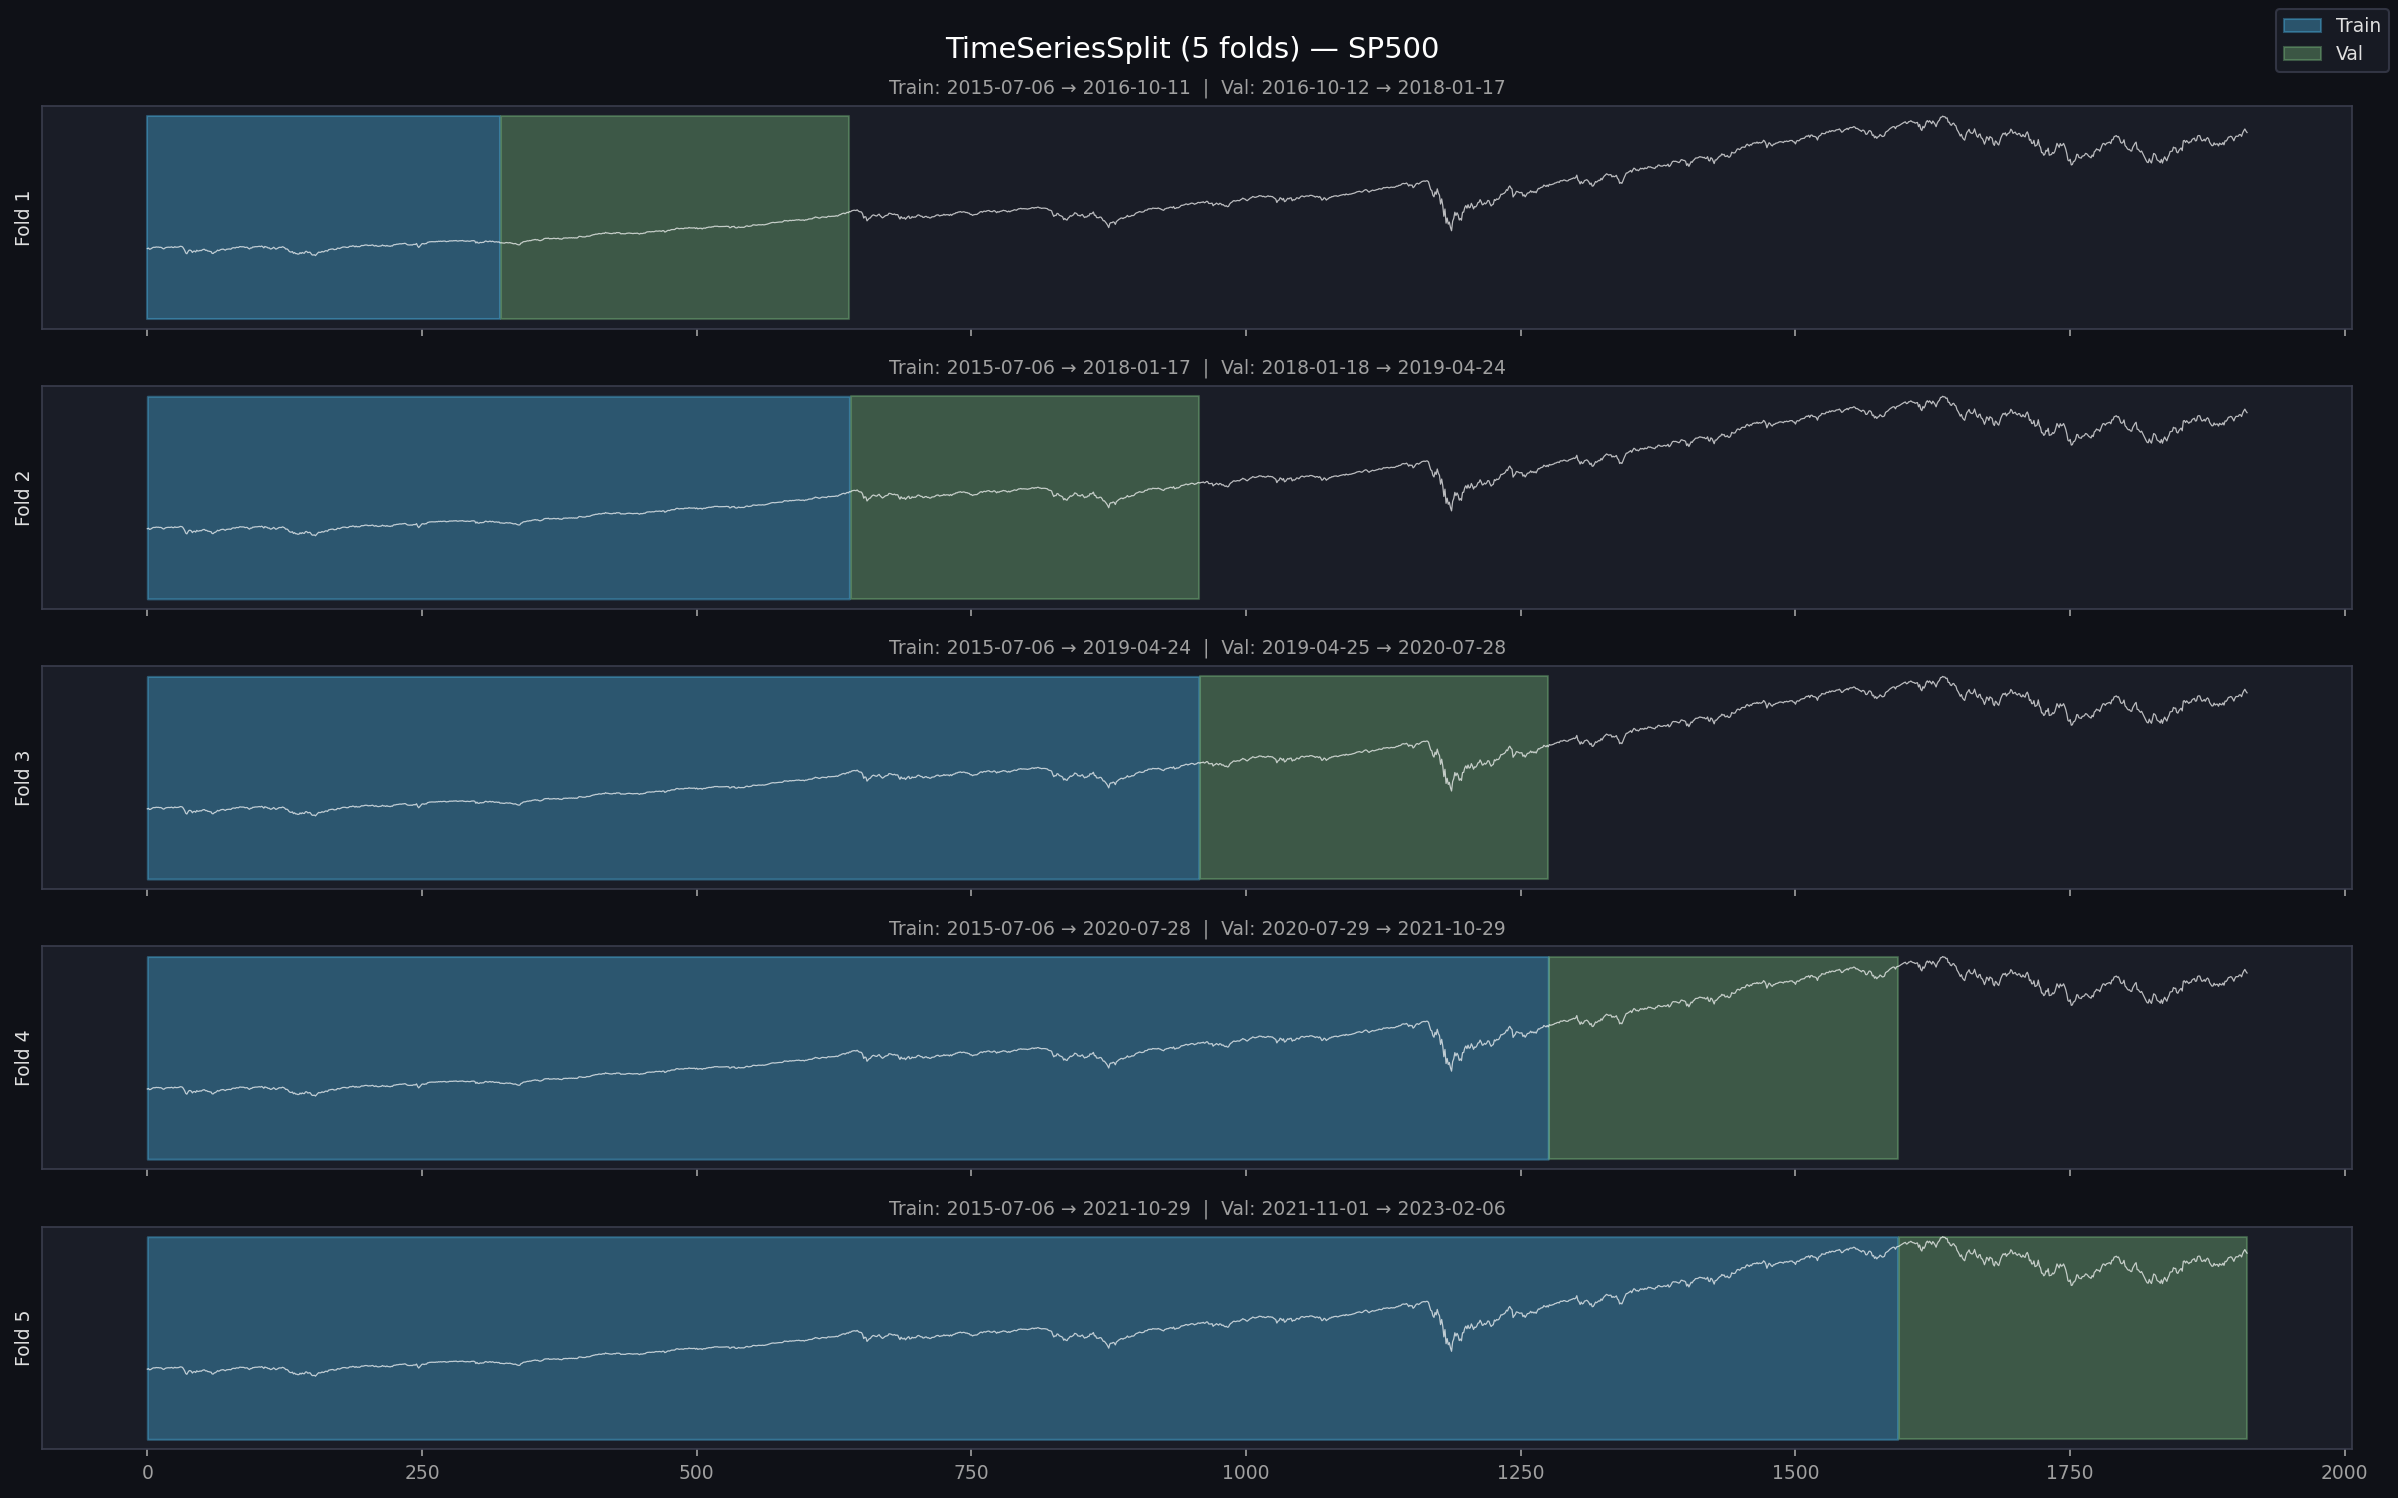

✅ TimeSeriesSplit diagram saved.


In [ ]:
# ─── TimeSeriesSplit ────────────────────────────────────
N_SPLITS = 5
tss = TimeSeriesSplit(n_splits=N_SPLITS)

# Use the training portion of the first available index as demo
demo_train, _, _ = temporal_split(demo_df, 0.80, 0.00)
demo_mean = demo_train.mean(axis=1).values
dates     = demo_train.index

fig, axes = plt.subplots(N_SPLITS, 1, figsize=(16, 10), sharex=True)
fig.suptitle(f'TimeSeriesSplit ({N_SPLITS} folds) — {demo_name}', fontsize=14, color='white')

for fold, (train_idx, val_idx) in enumerate(tss.split(demo_mean)):
    ax = axes[fold]
    ax.fill_between(range(len(dates)), 0, 1,
                    where=[i in set(train_idx) for i in range(len(dates))],
                    alpha=0.35, color=TRAIN_COLOR, label='Train' if fold == 0 else '')
    ax.fill_between(range(len(dates)), 0, 1,
                    where=[i in set(val_idx) for i in range(len(dates))],
                    alpha=0.35, color=VAL_COLOR, label='Val' if fold == 0 else '')

    ax.plot(demo_mean / demo_mean.max(), color='#ffffff', linewidth=0.6, alpha=0.7)
    ax.set_ylabel(f'Fold {fold+1}', fontsize=9)
    ax.set_yticks([])
    ax.grid(False)

    # Print dates
    tr_start = dates[train_idx[0]].date()
    tr_end_d = dates[train_idx[-1]].date()
    va_start = dates[val_idx[0]].date()
    va_end_d = dates[val_idx[-1]].date()
    ax.set_title(f'Train: {tr_start} → {tr_end_d}  |  Val: {va_start} → {va_end_d}',
                 fontsize=9, color='#a0a0a0')

fig.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('tss_crossfold.png', bbox_inches='tight')
plt.show()
print('✅ TimeSeriesSplit diagram saved.')

CPCV combinations: 15


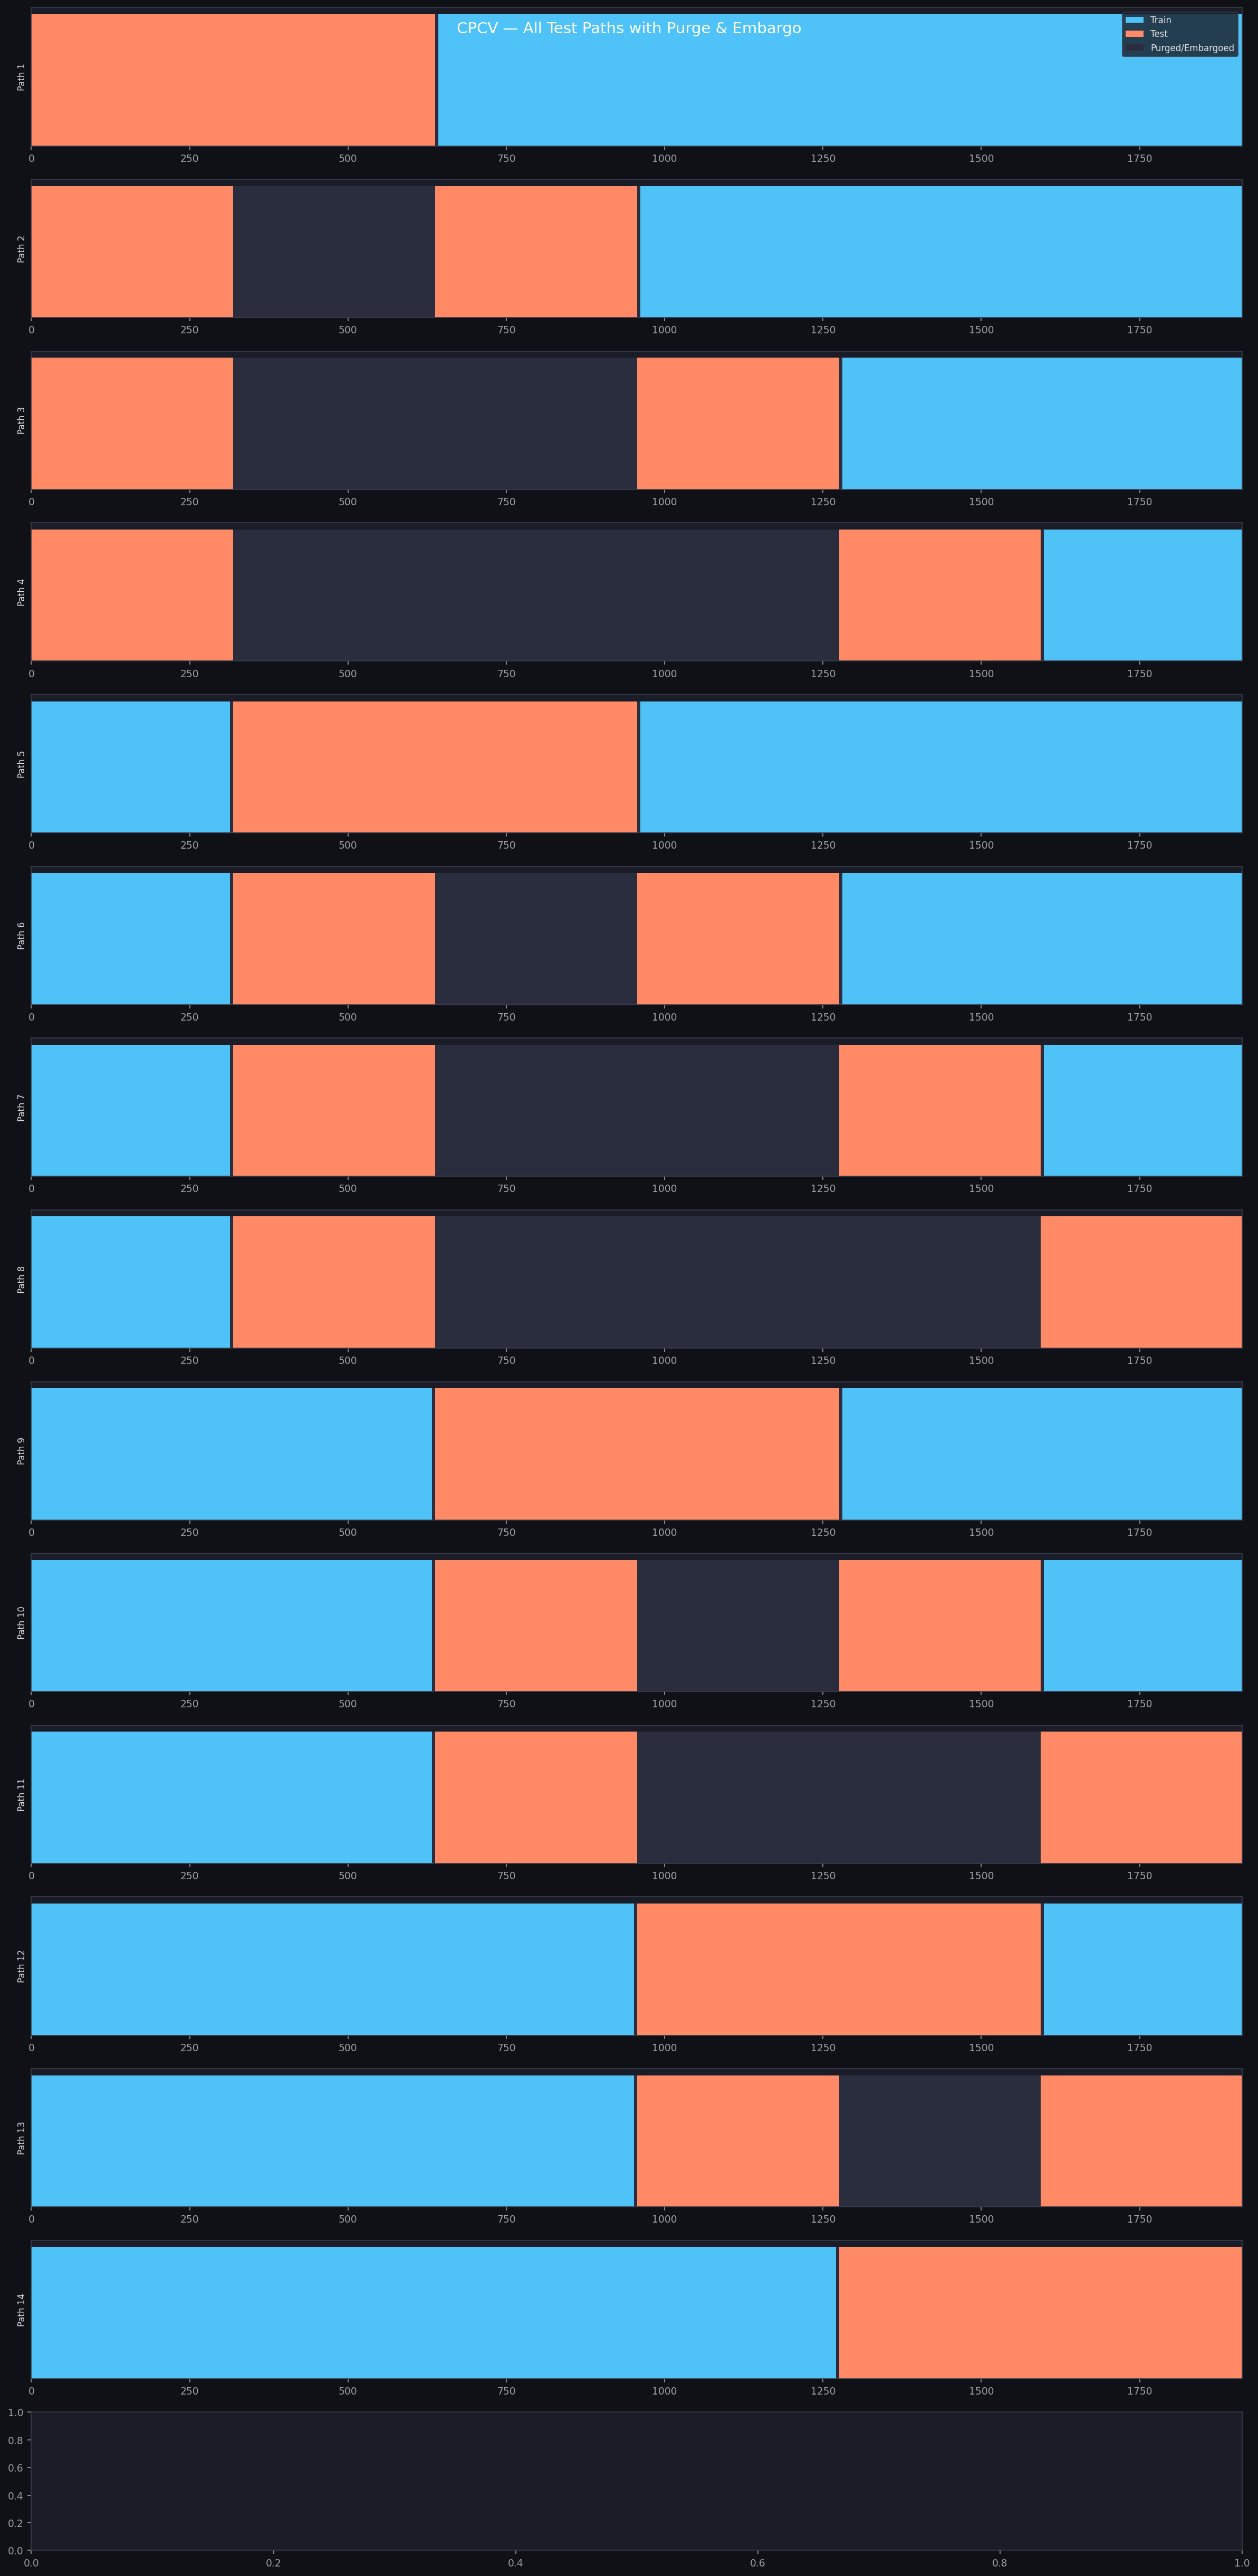

✅ CPCV diagram saved.


In [ ]:
class CPCV:
    """
    Combinatorial Purged Cross-Validation.

    Parameters
    ----------
    n_splits   : Total number of groups to divide the series into
    n_test_splits : Number of groups held out per combination (test path)
    purge_days : Number of days to purge around each test window
    embargo_days: Number of days to embargo after each test window
    """
    def __init__(self, n_splits=6, n_test_splits=2,
                 purge_days=5, embargo_days=5):
        self.n_splits      = n_splits
        self.n_test_splits = n_test_splits
        self.purge_days    = purge_days
        self.embargo_days  = embargo_days

    def split(self, X):
        n = len(X)
        indices = np.arange(n)
        groups  = np.array_split(indices, self.n_splits)

        for test_groups in combinations(range(self.n_splits), self.n_test_splits):
            test_idx  = np.concatenate([groups[g] for g in test_groups])
            test_min, test_max = test_idx.min(), test_idx.max()

            # Purge: remove samples within purge_days of the test window
            purge_mask = (indices >= test_min - self.purge_days) & \
                         (indices <= test_max + self.embargo_days)

            train_idx = indices[~purge_mask & ~np.isin(indices, test_idx)]

            if len(train_idx) == 0 or len(test_idx) == 0:
                continue
            yield train_idx, test_idx

    def n_combinations(self):
        from math import comb
        return comb(self.n_splits, self.n_test_splits)


# ─── Demonstrate CPCV ─────────────────────────────────────────────────────────
cpcv = CPCV(n_splits=6, n_test_splits=2, purge_days=5, embargo_days=5)
print(f'CPCV combinations: {cpcv.n_combinations()}')

fig, axes = plt.subplots(cpcv.n_combinations(), 1,
                          figsize=(16, 2.2 * cpcv.n_combinations()))
fig.suptitle('CPCV — All Test Paths with Purge & Embargo', fontsize=14, color='white')

for fold_i, (train_idx, test_idx) in enumerate(cpcv.split(demo_mean)):
    ax = axes[fold_i] if cpcv.n_combinations() > 1 else axes
    color_arr = ['#2a2d3d'] * len(demo_mean)  # background

    for ti in train_idx:
        color_arr[ti] = TRAIN_COLOR
    for ti in test_idx:
        color_arr[ti] = TEST_COLOR

    # Draw as colored bar chart
    ax.bar(range(len(demo_mean)), [1]*len(demo_mean),
           color=color_arr, width=1, linewidth=0)
    ax.set_yticks([])
    ax.set_ylabel(f'Path {fold_i+1}', fontsize=8)
    ax.set_xlim(0, len(demo_mean))

    # Legend on first fold only
    if fold_i == 0:
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(facecolor=TRAIN_COLOR, label='Train'),
            Patch(facecolor=TEST_COLOR,  label='Test'),
            Patch(facecolor='#2a2d3d',   label='Purged/Embargoed'),
        ], loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('cpcv_paths.png', bbox_inches='tight')
plt.show()
print('✅ CPCV diagram saved.')

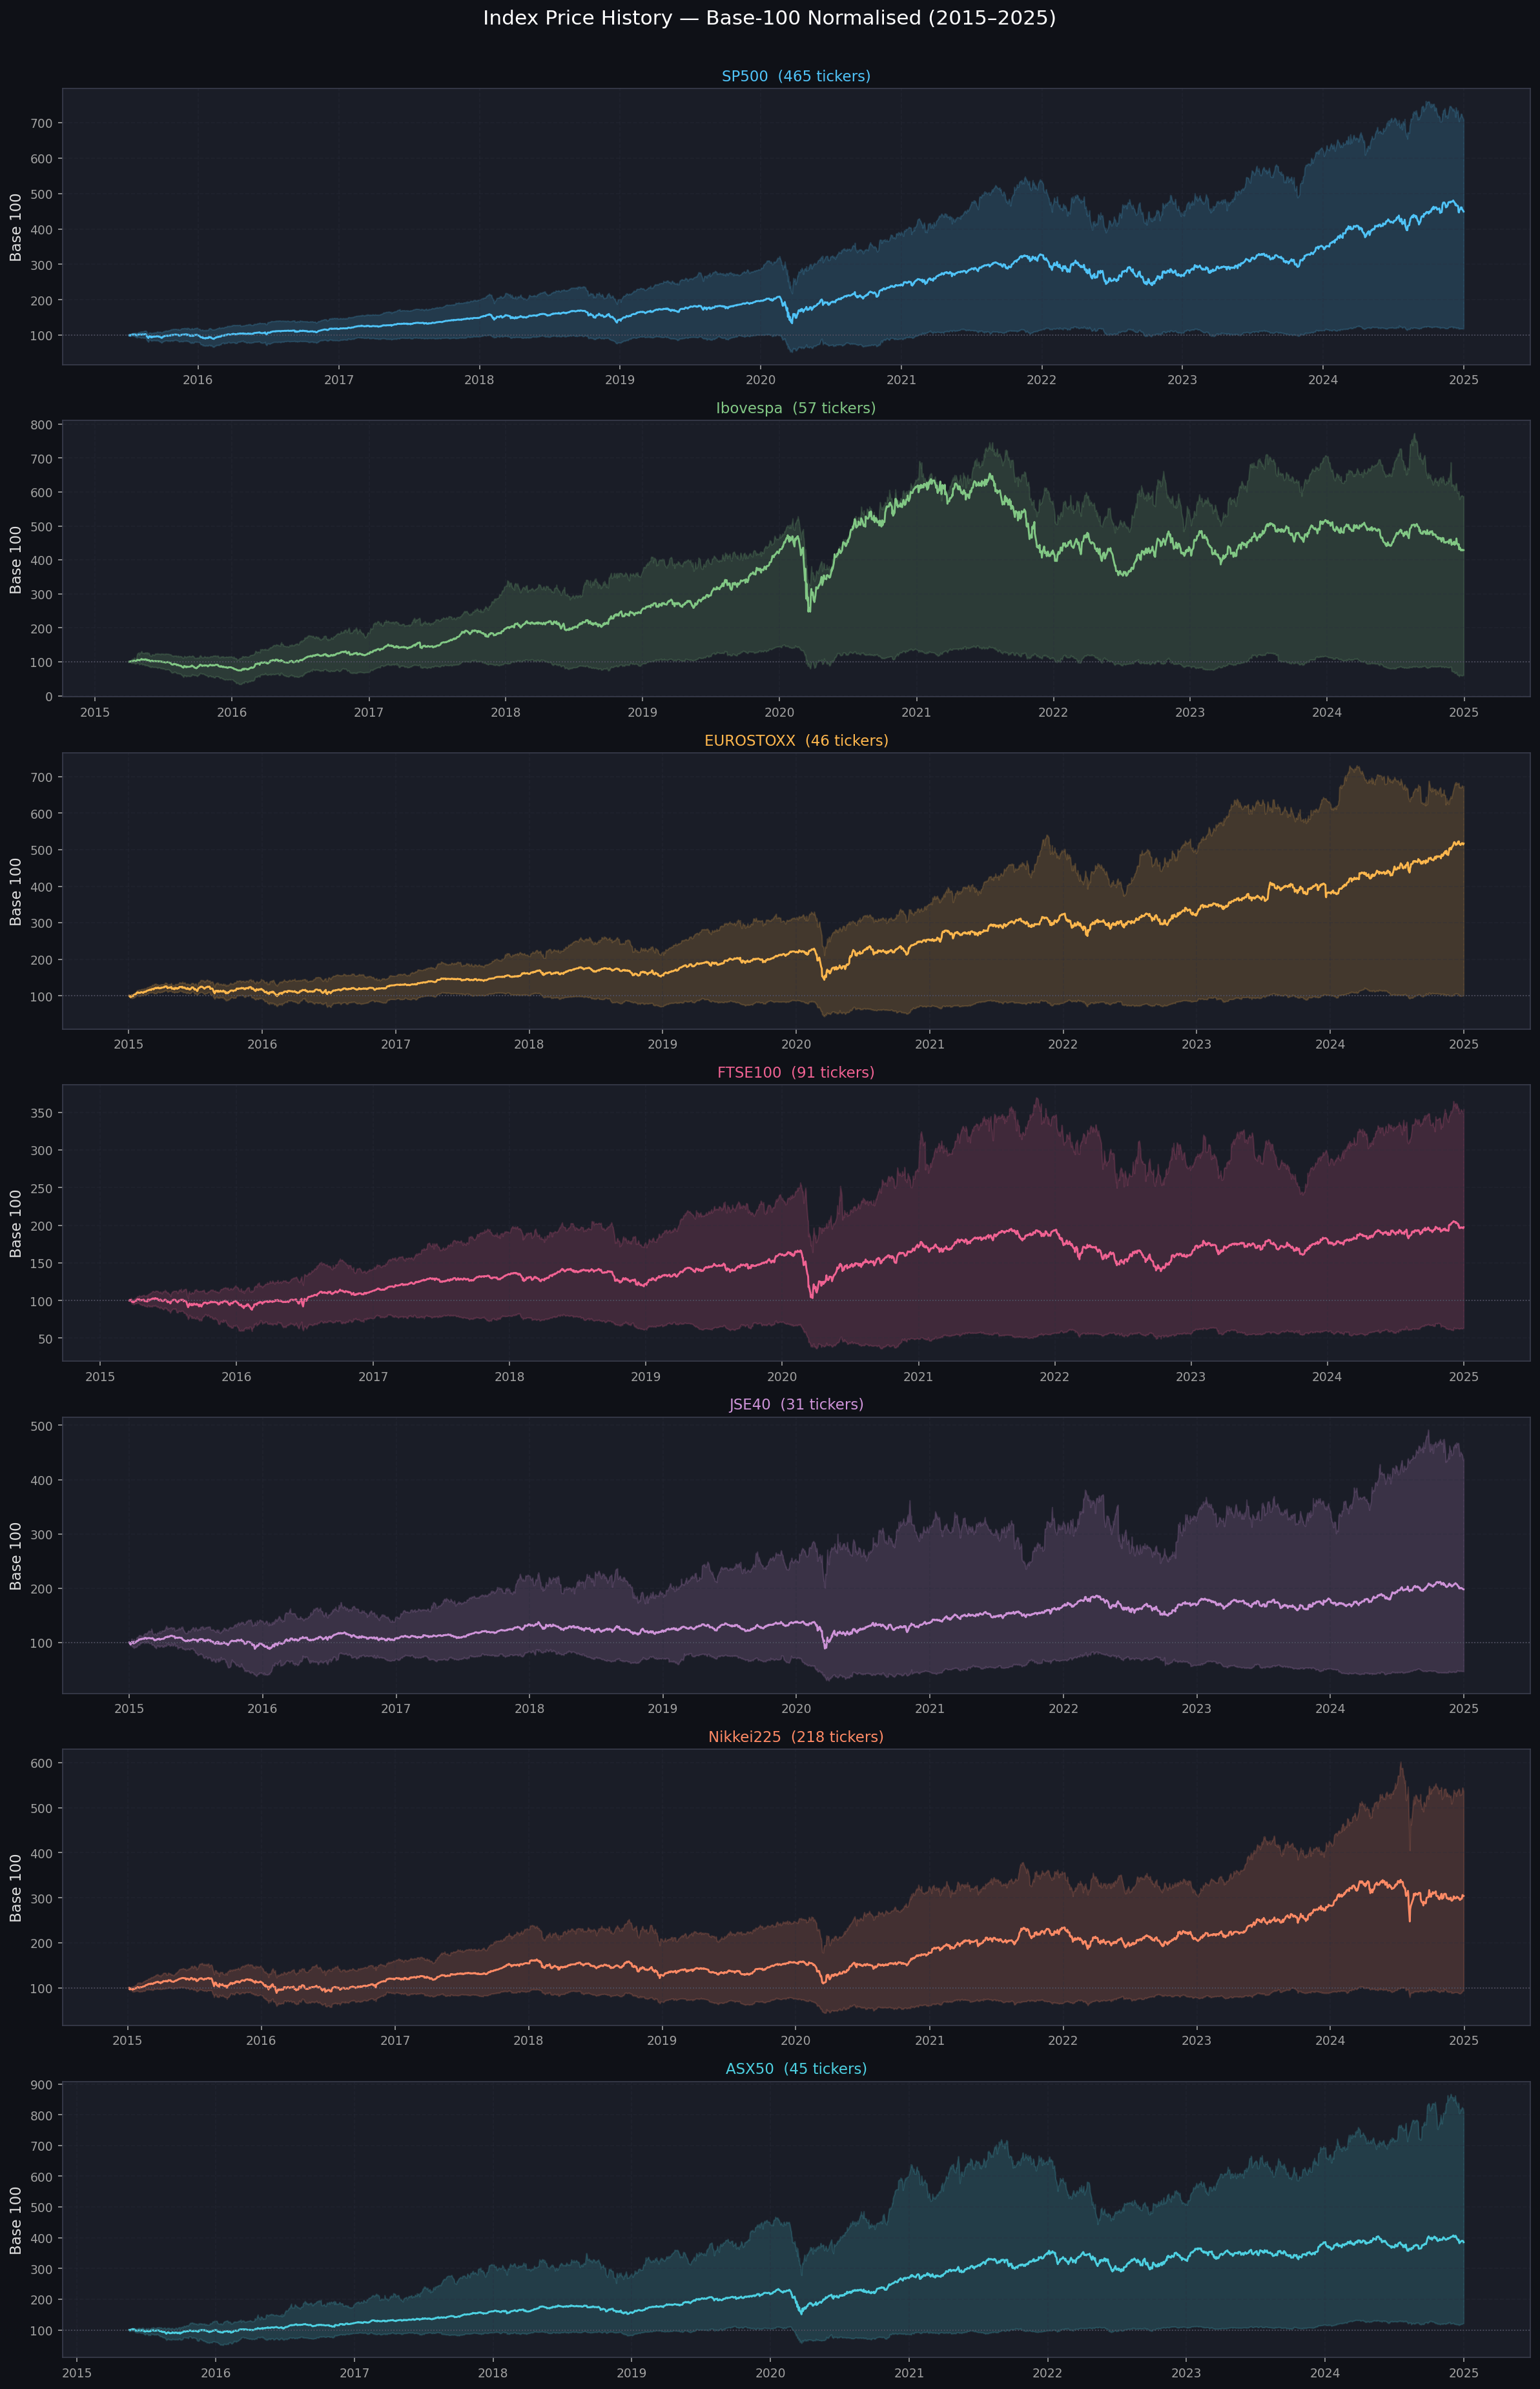

✅ Price charts saved.


In [ ]:
fig, axes = plt.subplots(len(index_data), 1, figsize=(16, 3.5 * len(index_data)), sharex=False)
if len(index_data) == 1:
    axes = [axes]

fig.suptitle('Index Price History — Base-100 Normalised (2015–2025)', fontsize=15, color='white', y=1.005)

for ax, (name, df) in zip(axes, index_data.items()):
    color = INDEX_COLORS.get(name, '#ffffff')
    base100 = normalise_base100(df)
    mean_series = base100.mean(axis=1)
    p10 = base100.quantile(0.10, axis=1)
    p90 = base100.quantile(0.90, axis=1)

    ax.fill_between(mean_series.index, p10, p90, alpha=0.18, color=color)
    ax.plot(mean_series, color=color, linewidth=1.4, label='Mean')
    ax.axhline(100, color='#555566', linestyle=':', linewidth=0.8)

    ax.set_title(f'{name}  ({df.shape[1]} tickers)', fontsize=11, color=color)
    ax.set_ylabel('Base 100')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('price_charts_base100.png', bbox_inches='tight')
plt.show()
print('✅ Price charts saved.')

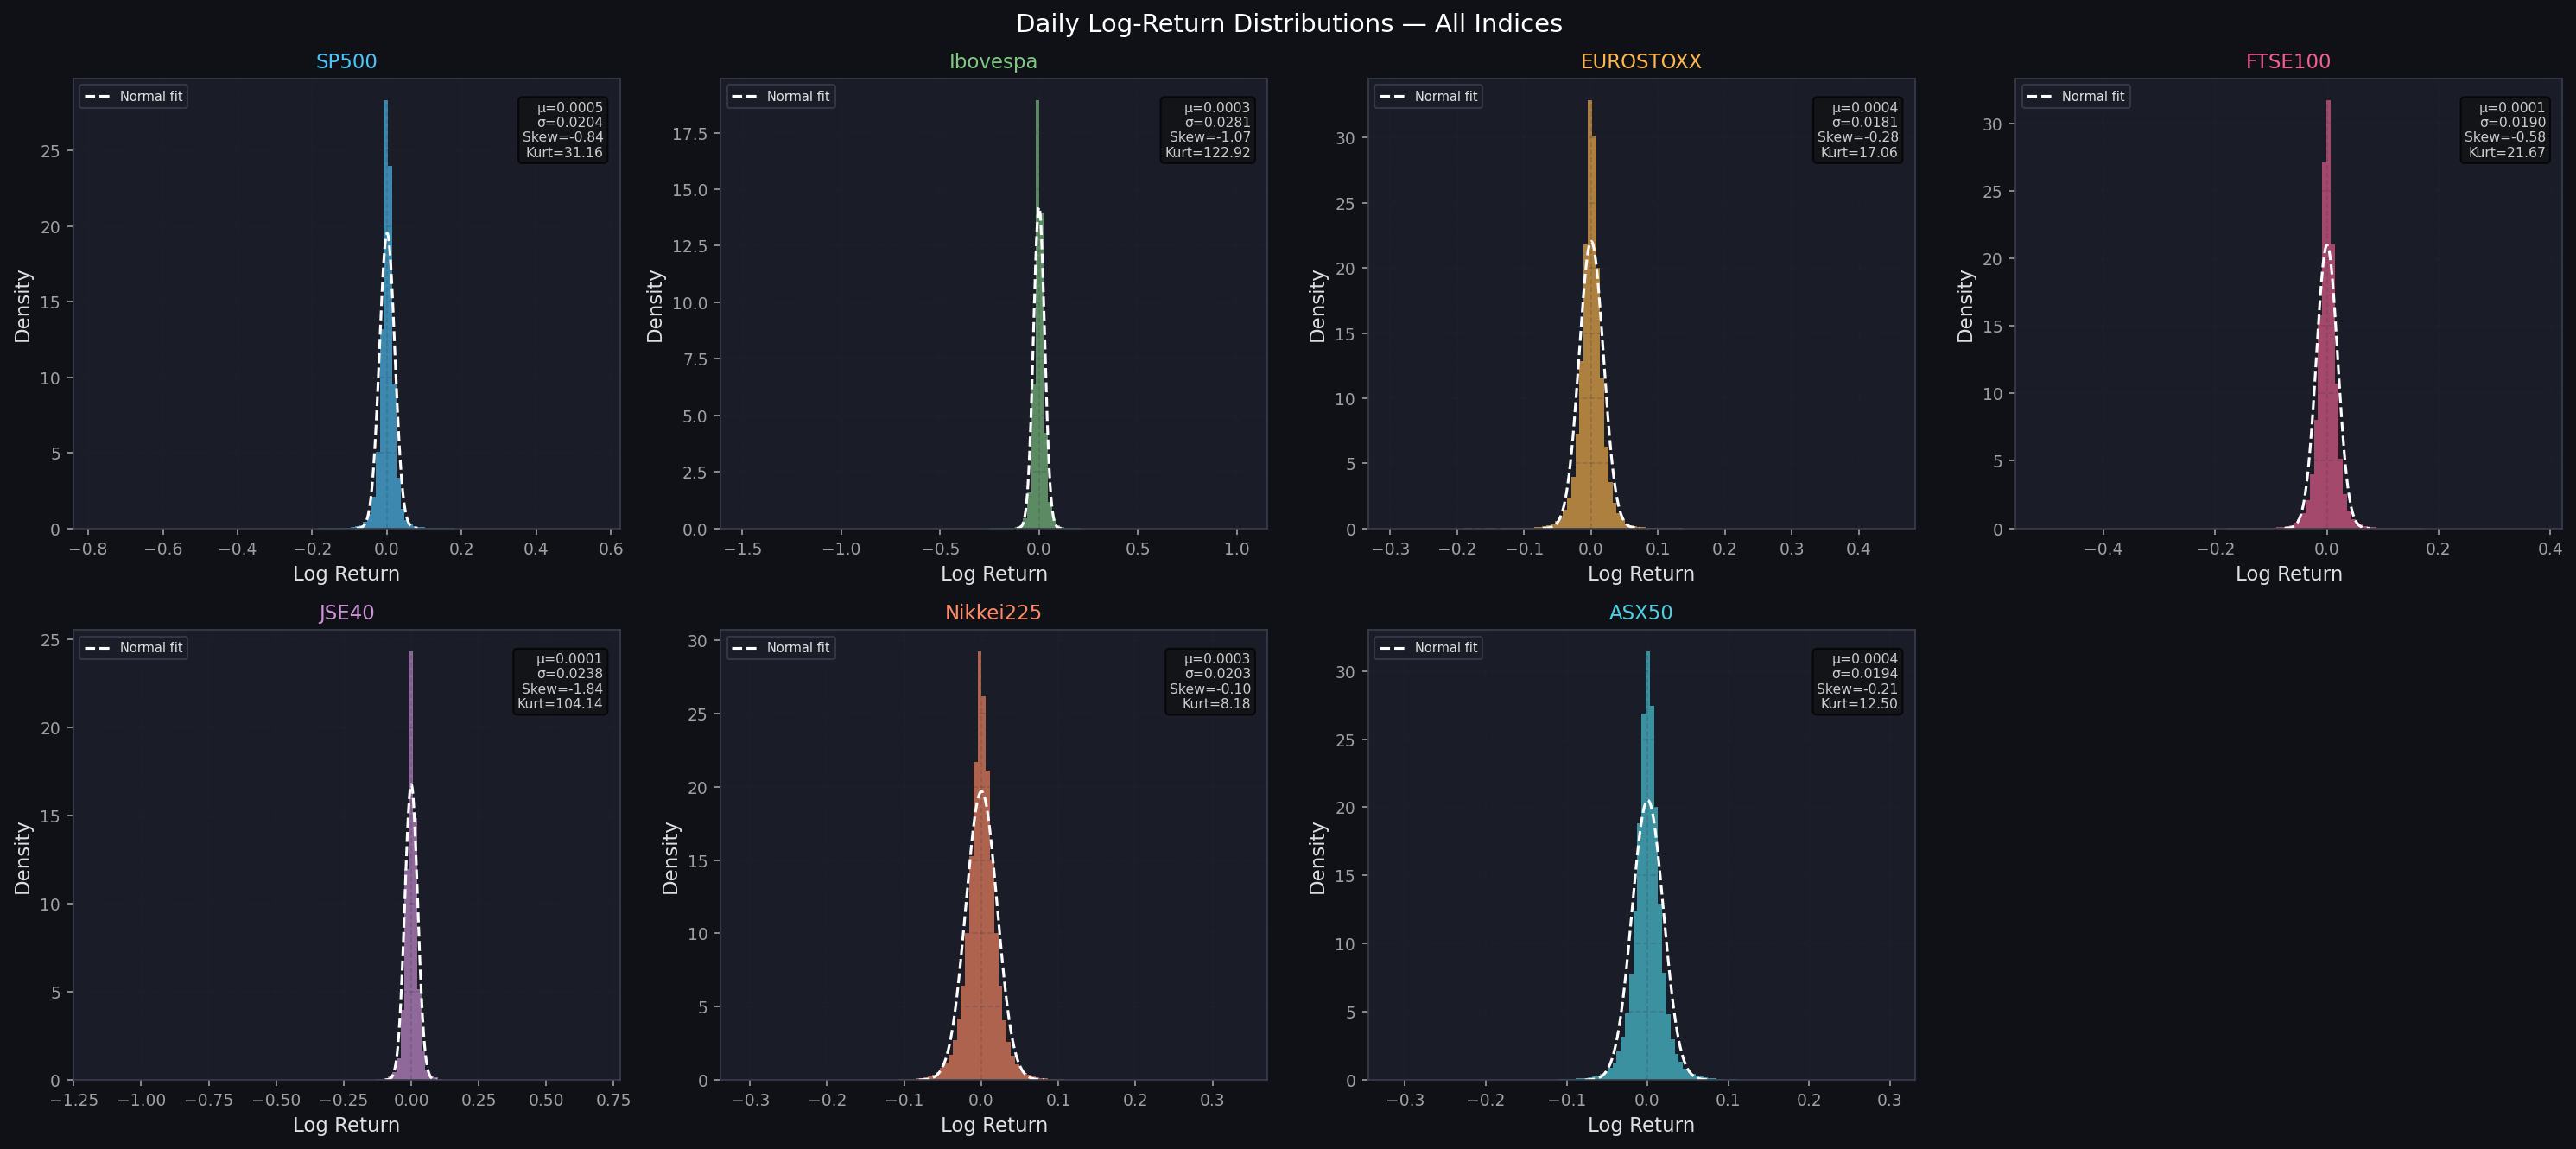

✅ Return distributions saved.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
fig.suptitle('Daily Log-Return Distributions — All Indices', fontsize=14, color='white')

for i, (name, df) in enumerate(index_data.items()):
    ax = axes[i]
    color = INDEX_COLORS.get(name, '#ffffff')

    log_returns = np.log(df / df.shift(1)).dropna()
    all_returns = log_returns.values.flatten()
    all_returns = all_returns[~np.isnan(all_returns)]

    # Histogram
    ax.hist(all_returns, bins=120, color=color, alpha=0.65, density=True, edgecolor='none')

    # Normal overlay
    mu, sigma = all_returns.mean(), all_returns.std()
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            color='white', linewidth=1.5, linestyle='--', label='Normal fit')

    skew = stats.skew(all_returns)
    kurt = stats.kurtosis(all_returns)
    ax.set_title(name, color=color, fontsize=11)
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Density')
    ax.text(0.97, 0.95, f'μ={mu:.4f}\nσ={sigma:.4f}\nSkew={skew:.2f}\nKurt={kurt:.2f}',
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right',
            color='#cccccc', bbox=dict(boxstyle='round,pad=0.3', facecolor='#111', alpha=0.7))
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

# Hide unused panel
for j in range(len(index_data), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('return_distributions.png', bbox_inches='tight')
plt.show()
print('✅ Return distributions saved.')

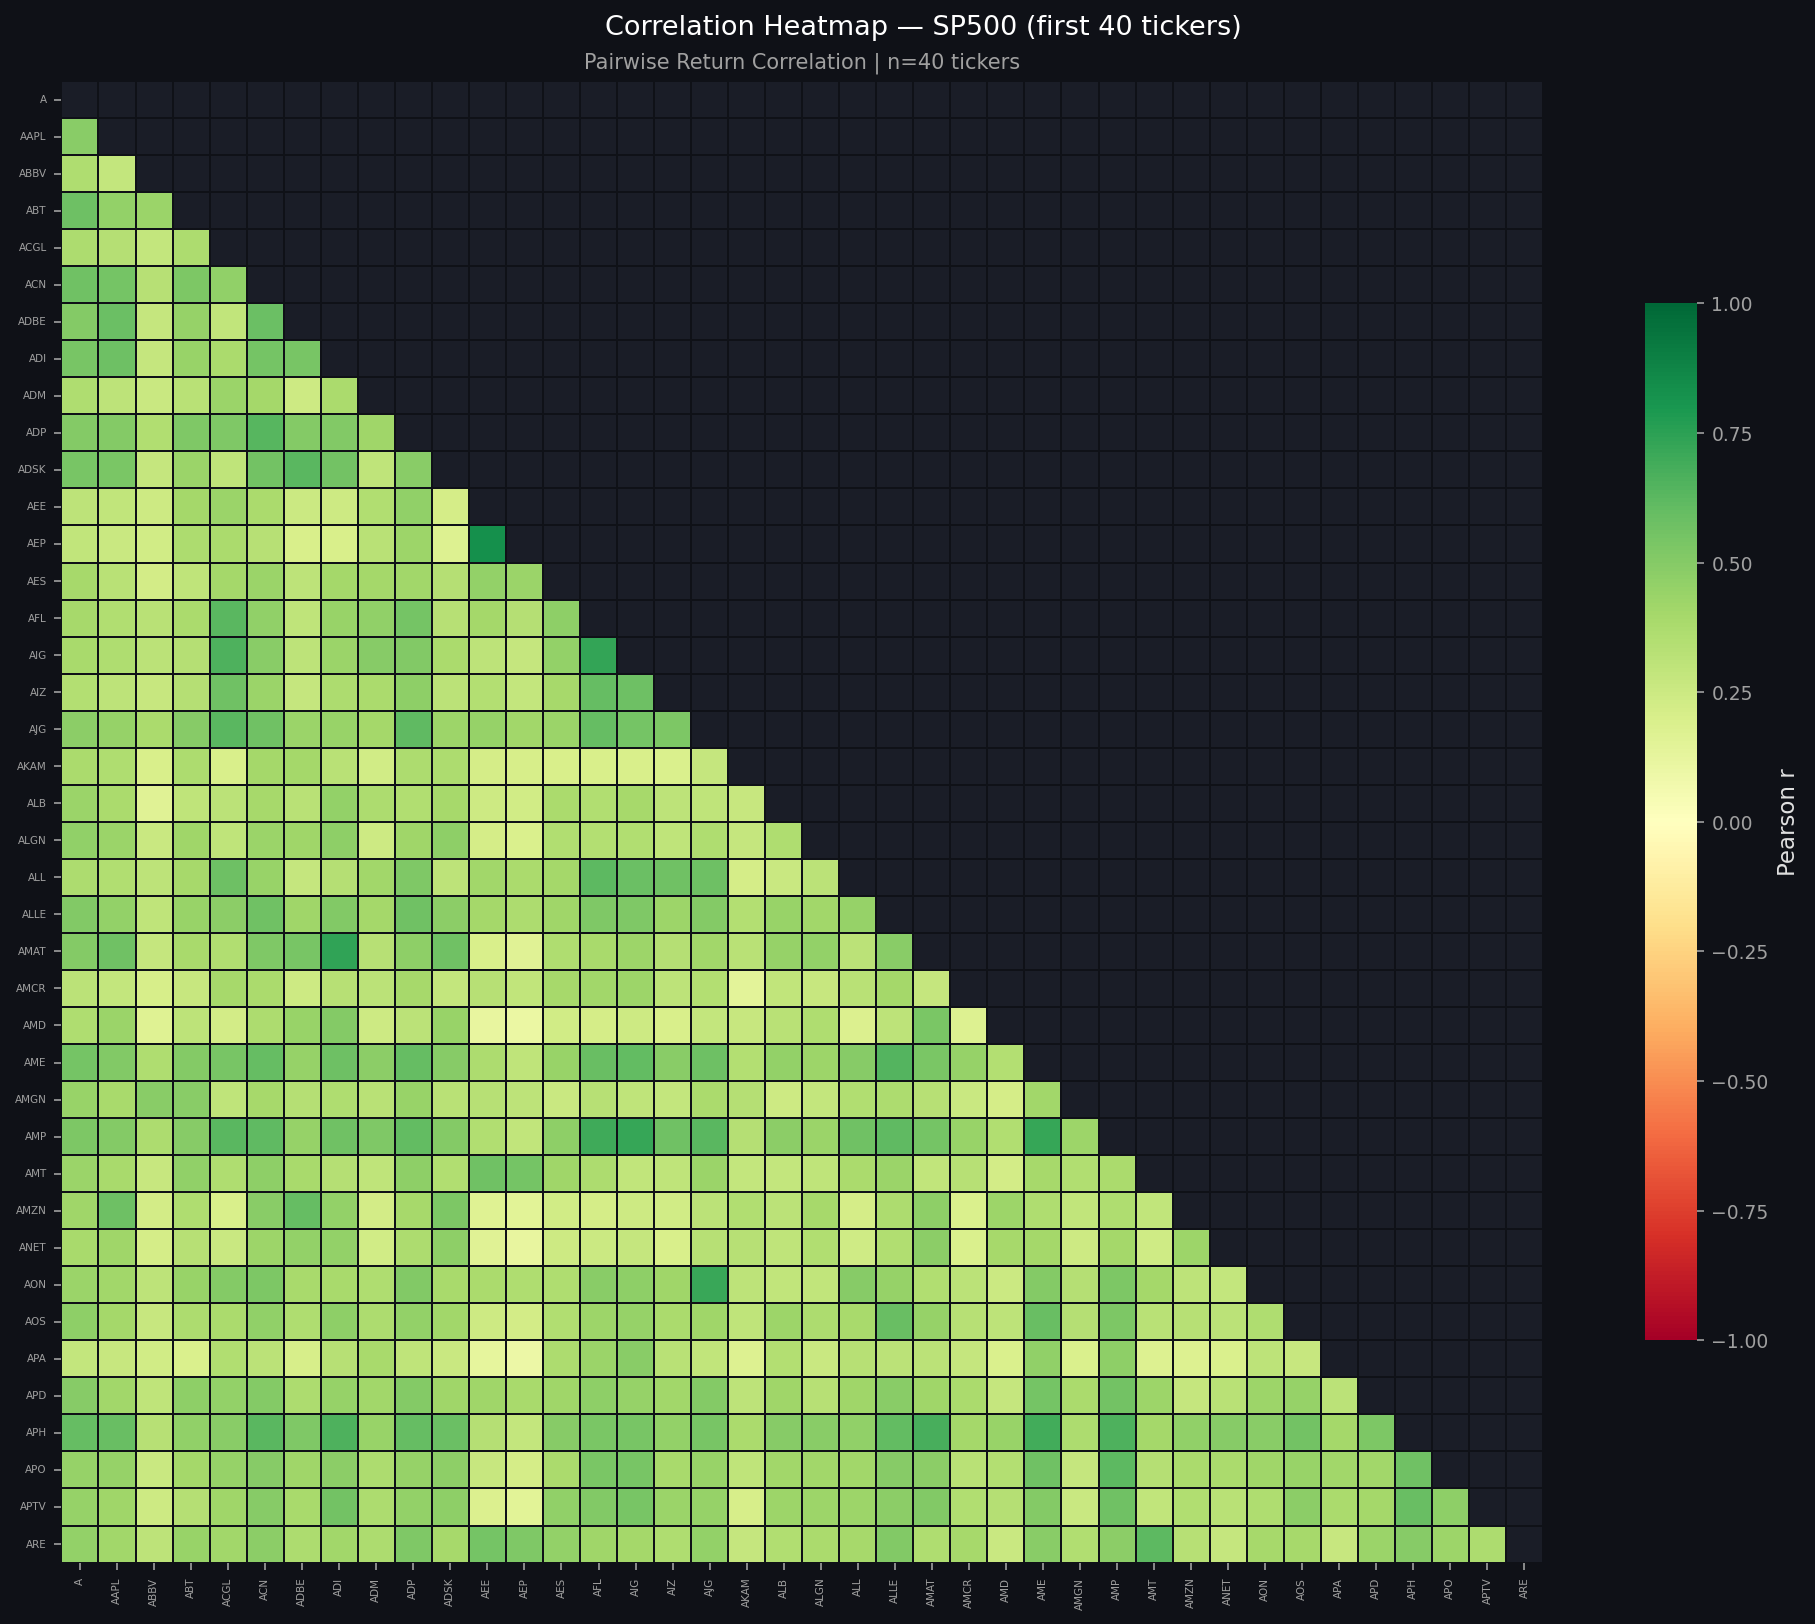

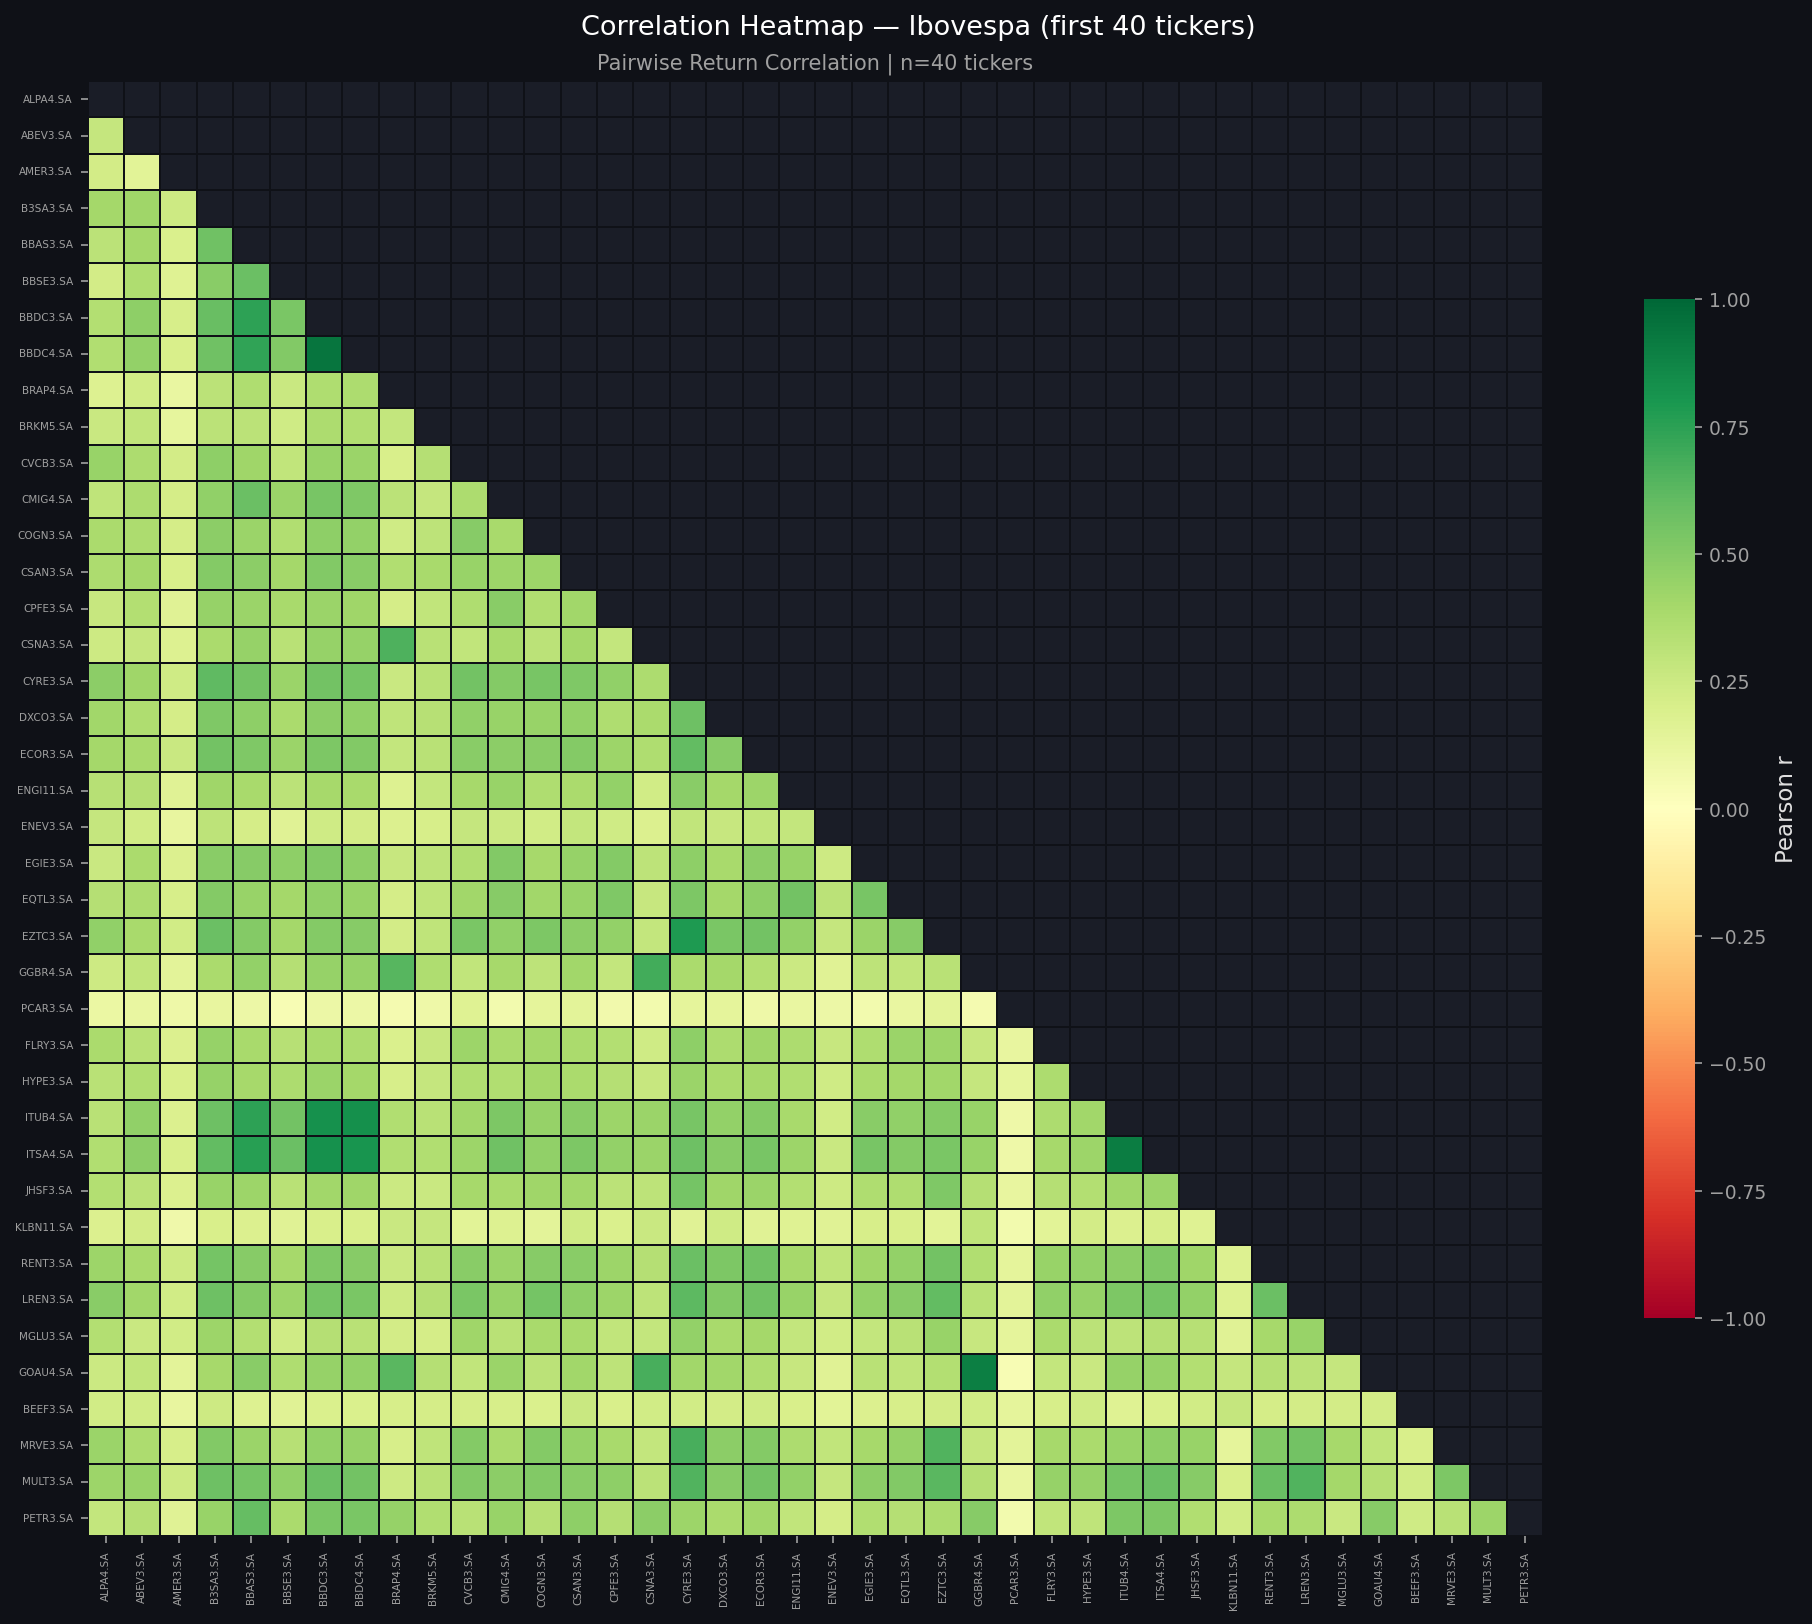

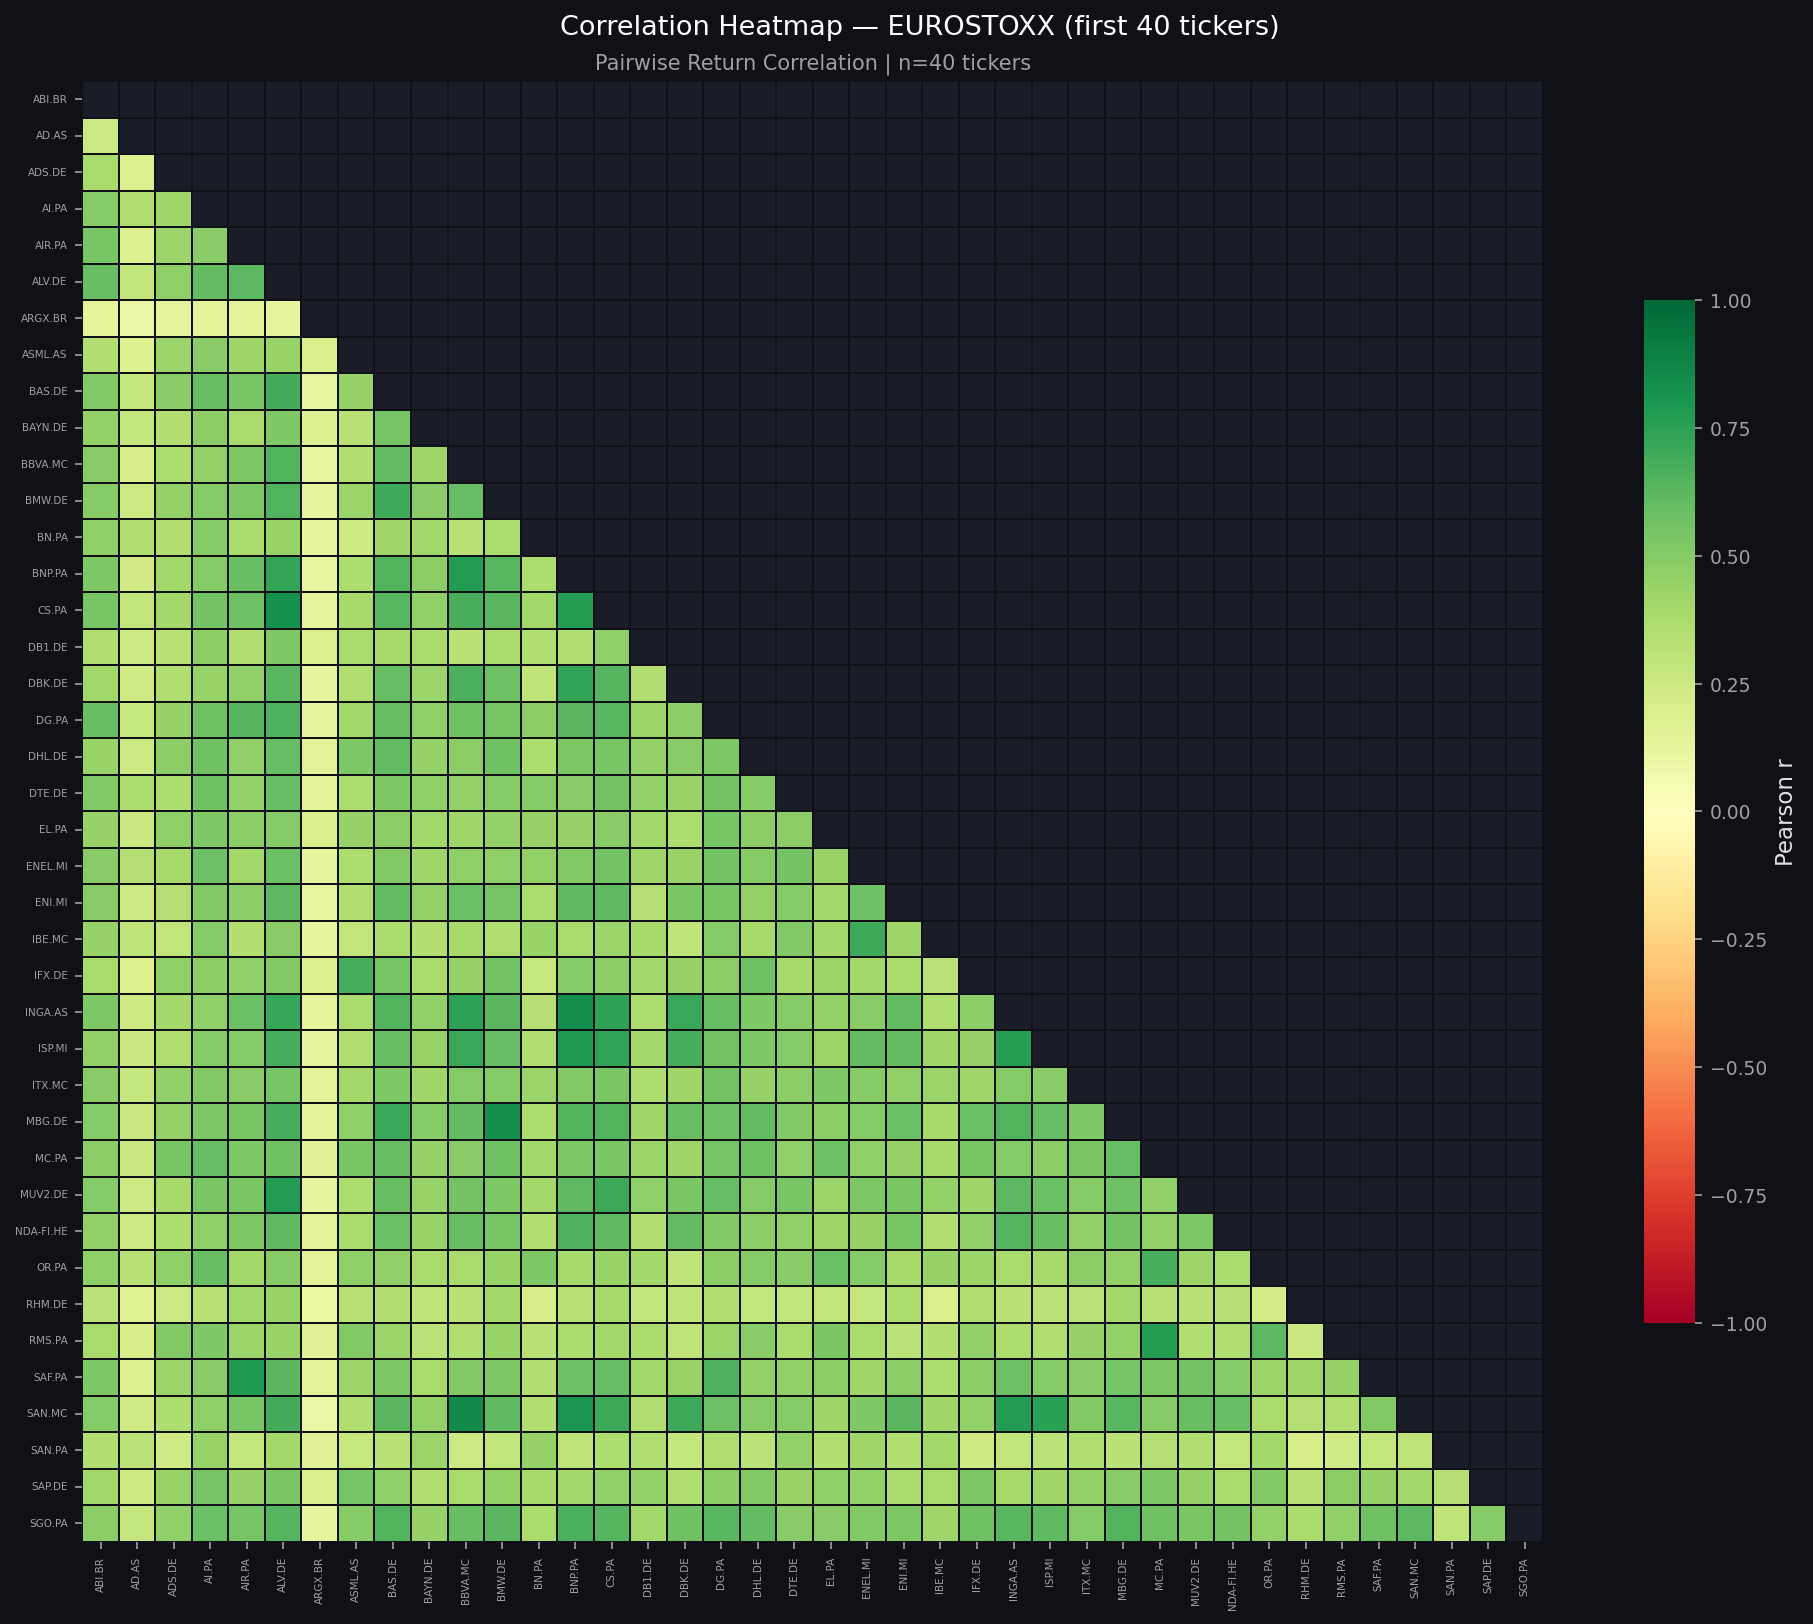

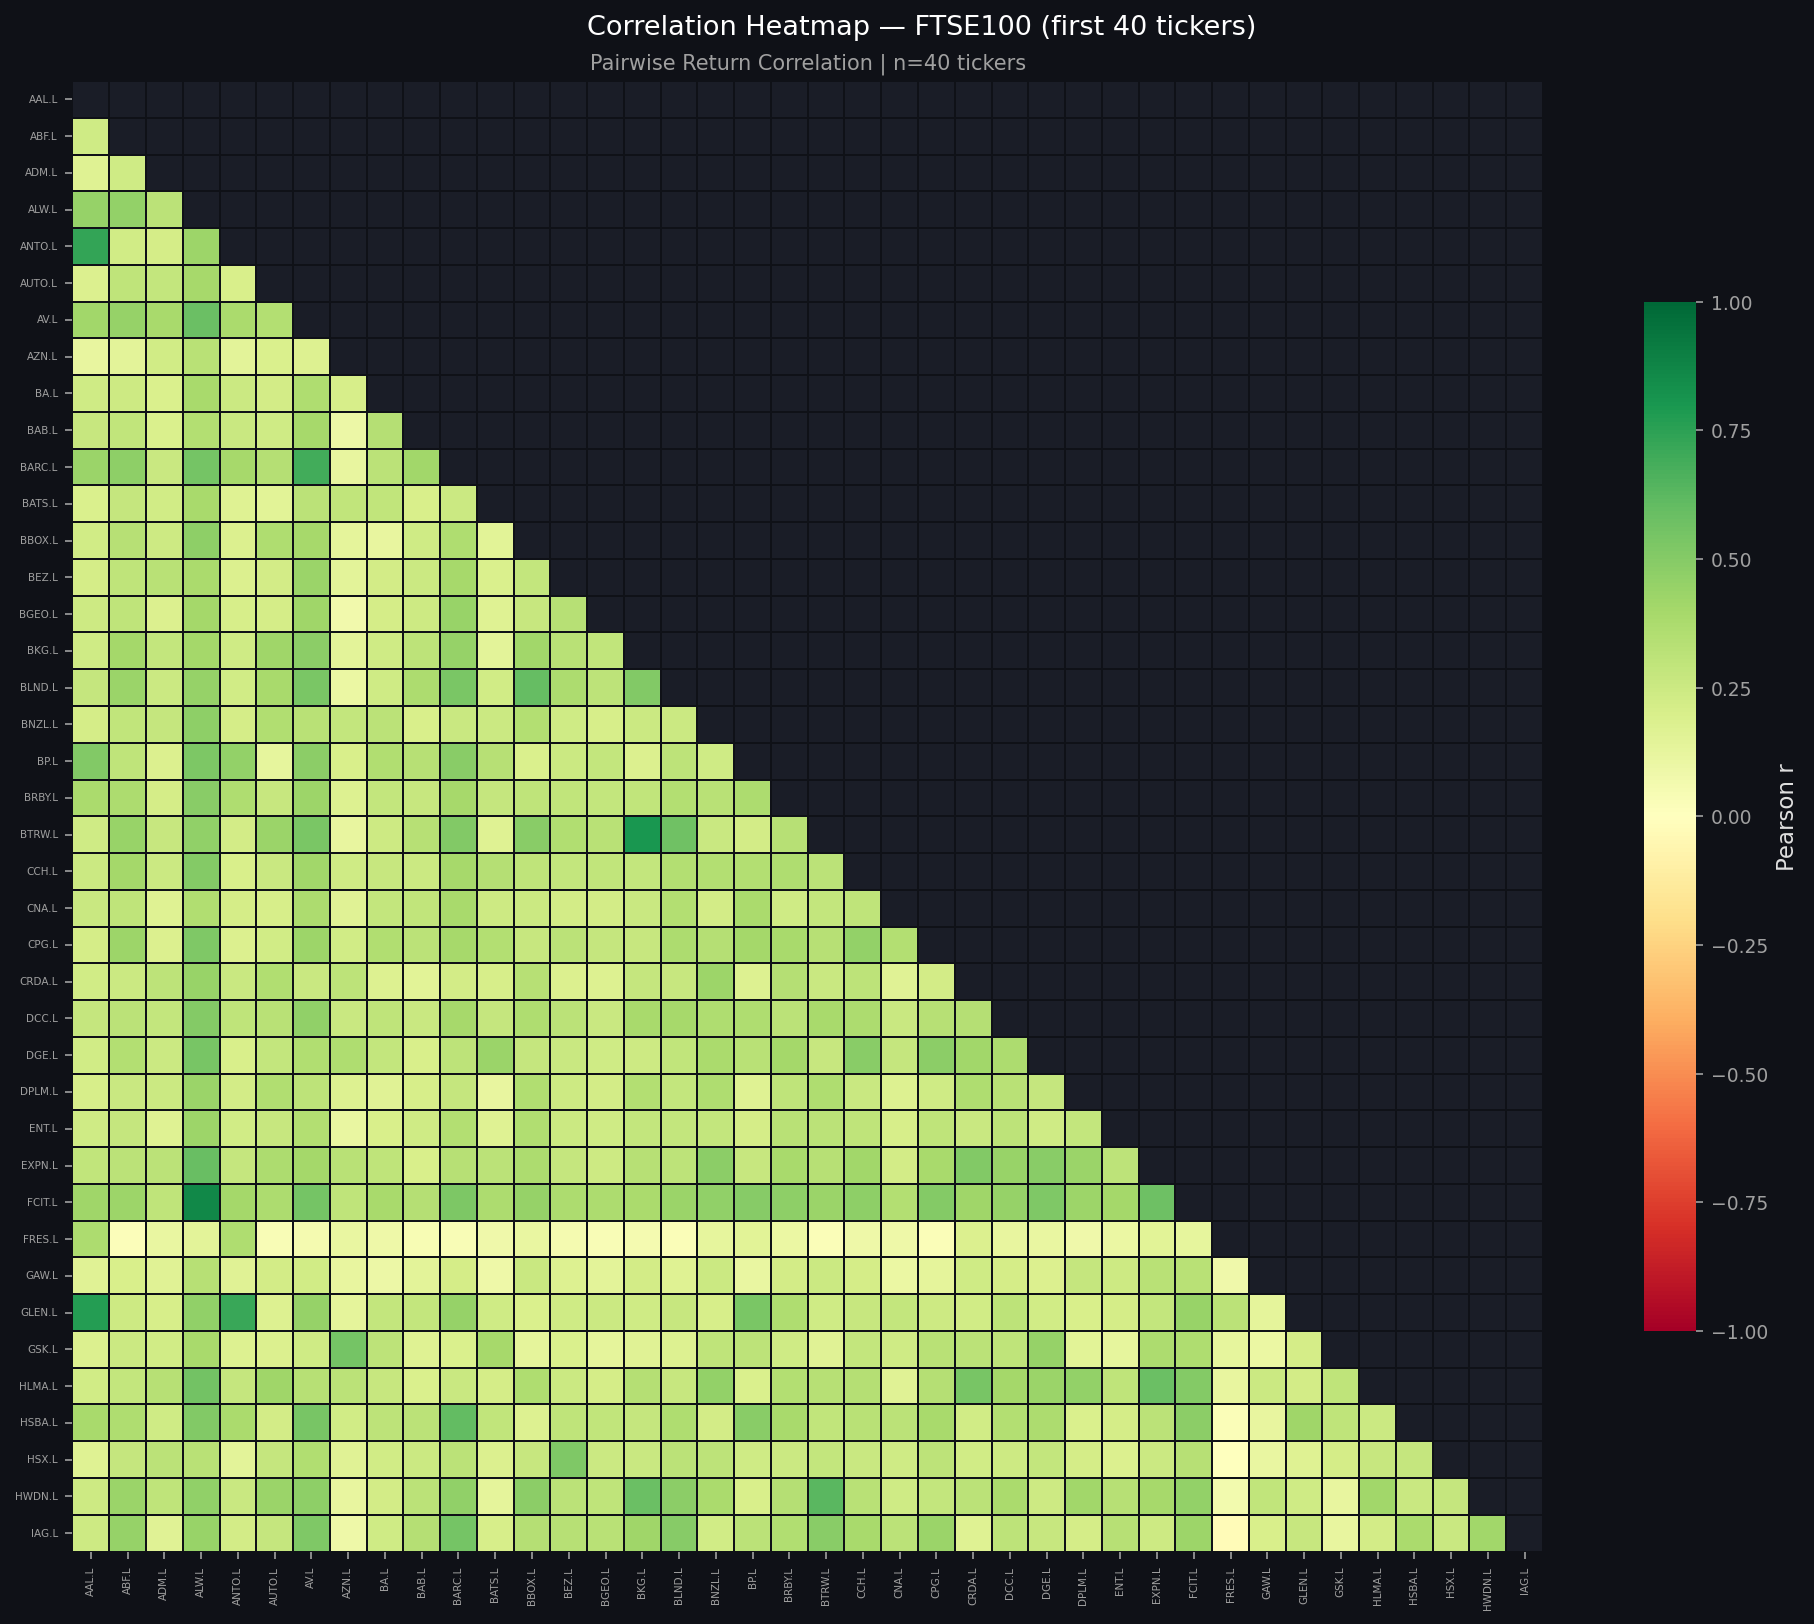

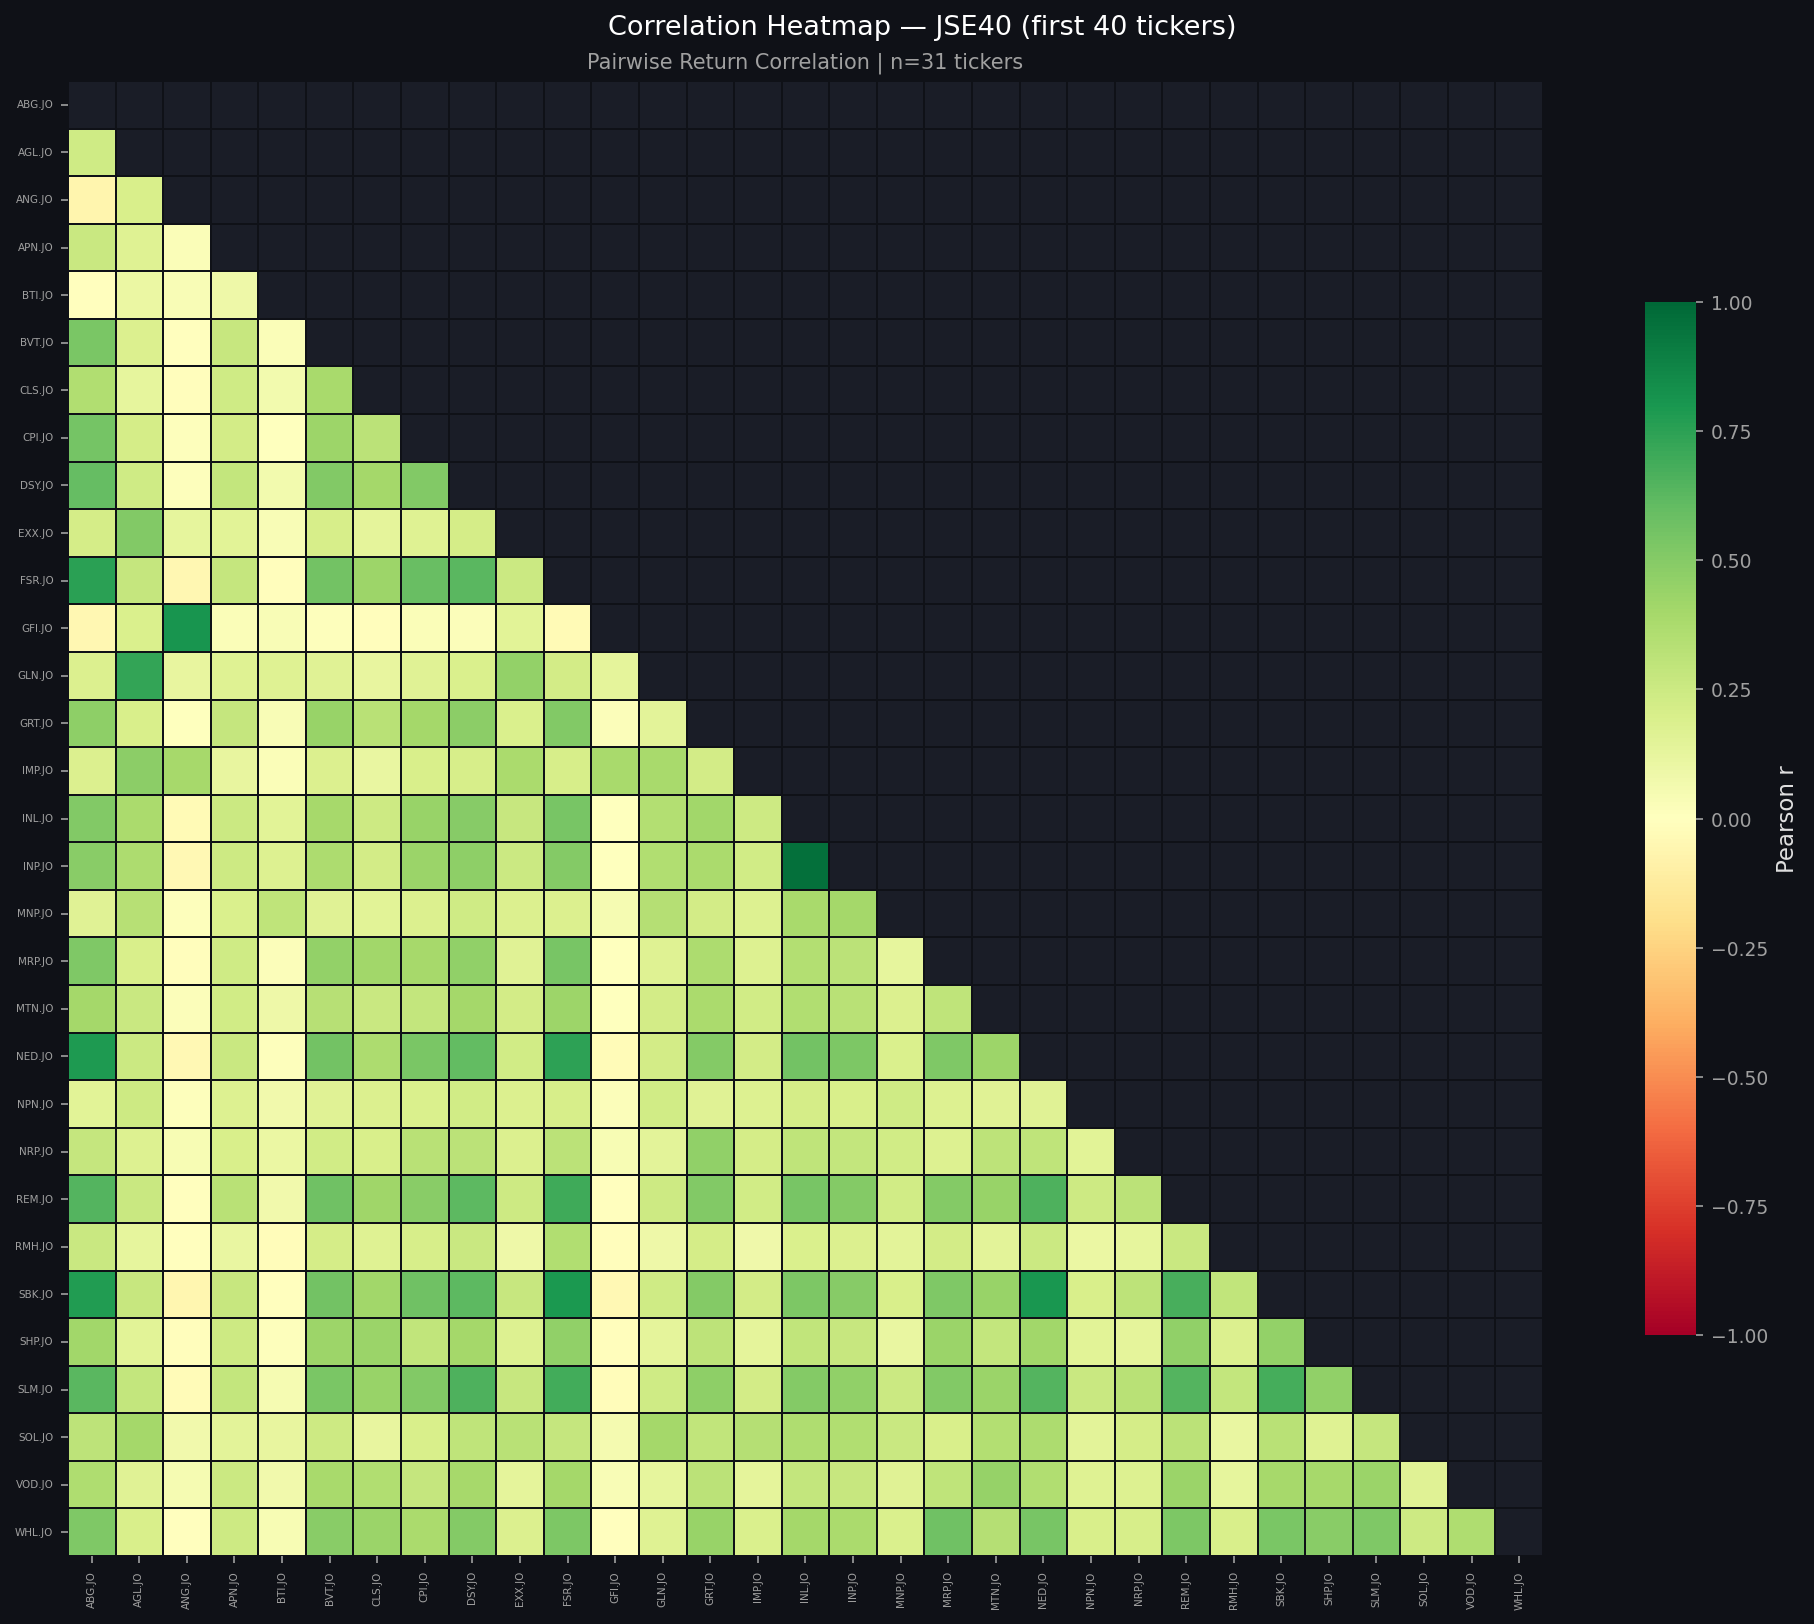

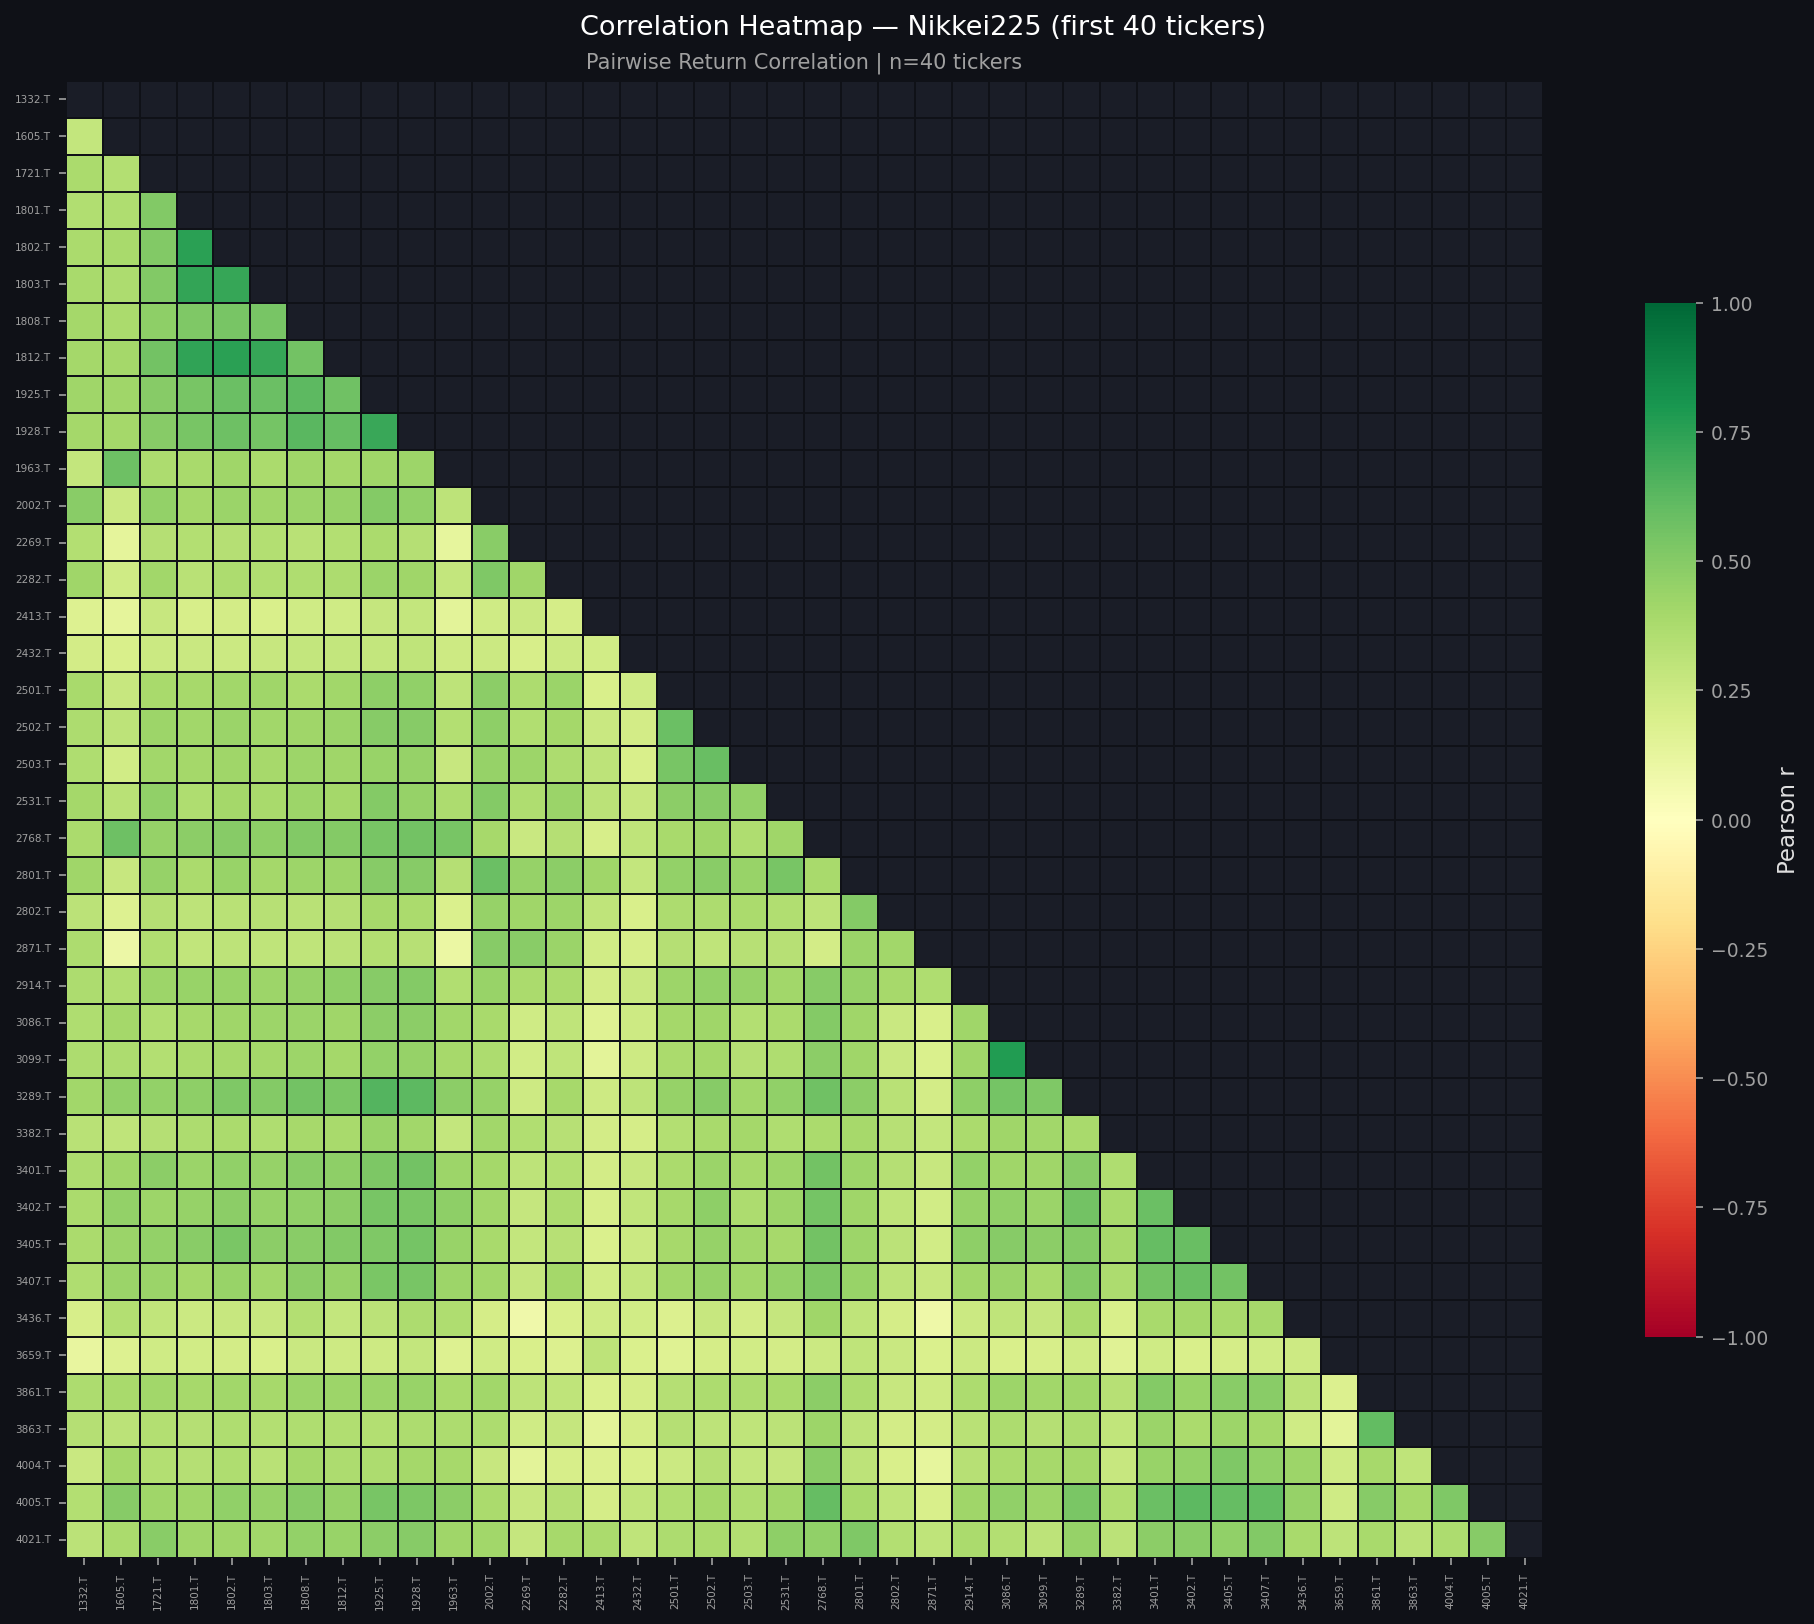

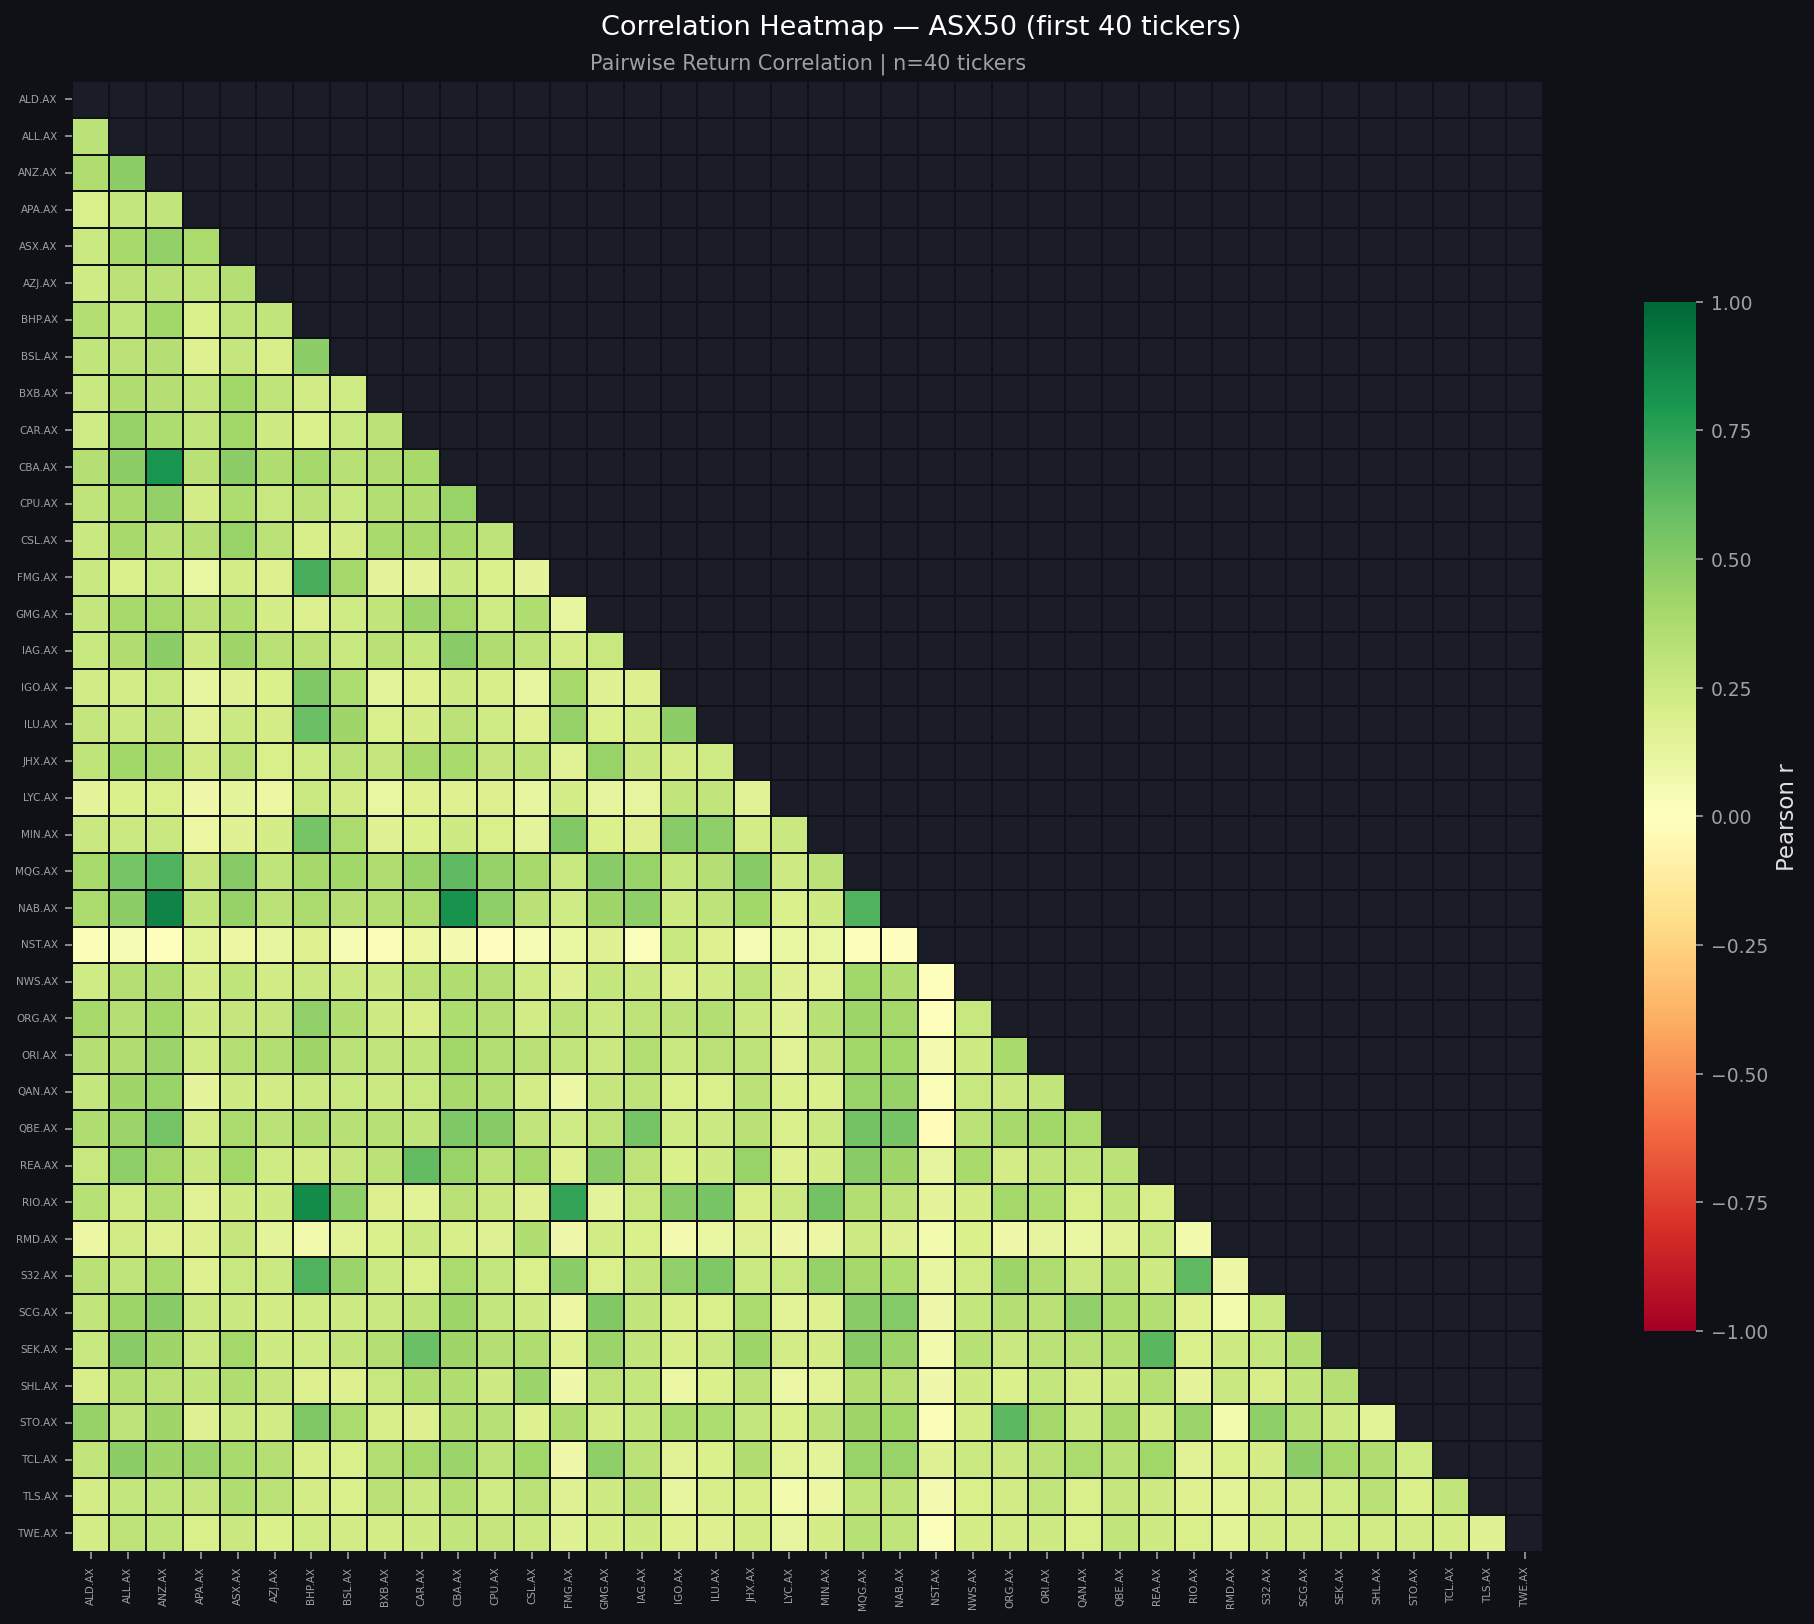

✅ Within-index correlation heatmaps saved.


In [ ]:
for name, df in index_data.items():
    log_ret = np.log(df / df.shift(1)).dropna()

    # Limit to 40 tickers for readability
    if log_ret.shape[1] > 40:
        log_ret = log_ret.iloc[:, :40]

    corr = log_ret.corr()

    fig, ax = plt.subplots(figsize=(14, 11))
    fig.suptitle(f'Correlation Heatmap — {name} (first 40 tickers)', color='white', fontsize=13)

    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, ax=ax, mask=mask,
        cmap='RdYlGn', center=0, vmin=-1, vmax=1,
        linewidths=0.2, linecolor='#0f1117',
        annot=False, square=True,
        cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}
    )
    ax.set_title(f'Pairwise Return Correlation | n={corr.shape[0]} tickers', color='#a0a0a0', fontsize=10)
    ax.tick_params(axis='both', labelsize=5)

    plt.tight_layout()
    plt.savefig(f'corr_heatmap_{name.lower()}.png', bbox_inches='tight')
    plt.show()

print('✅ Within-index correlation heatmaps saved.')

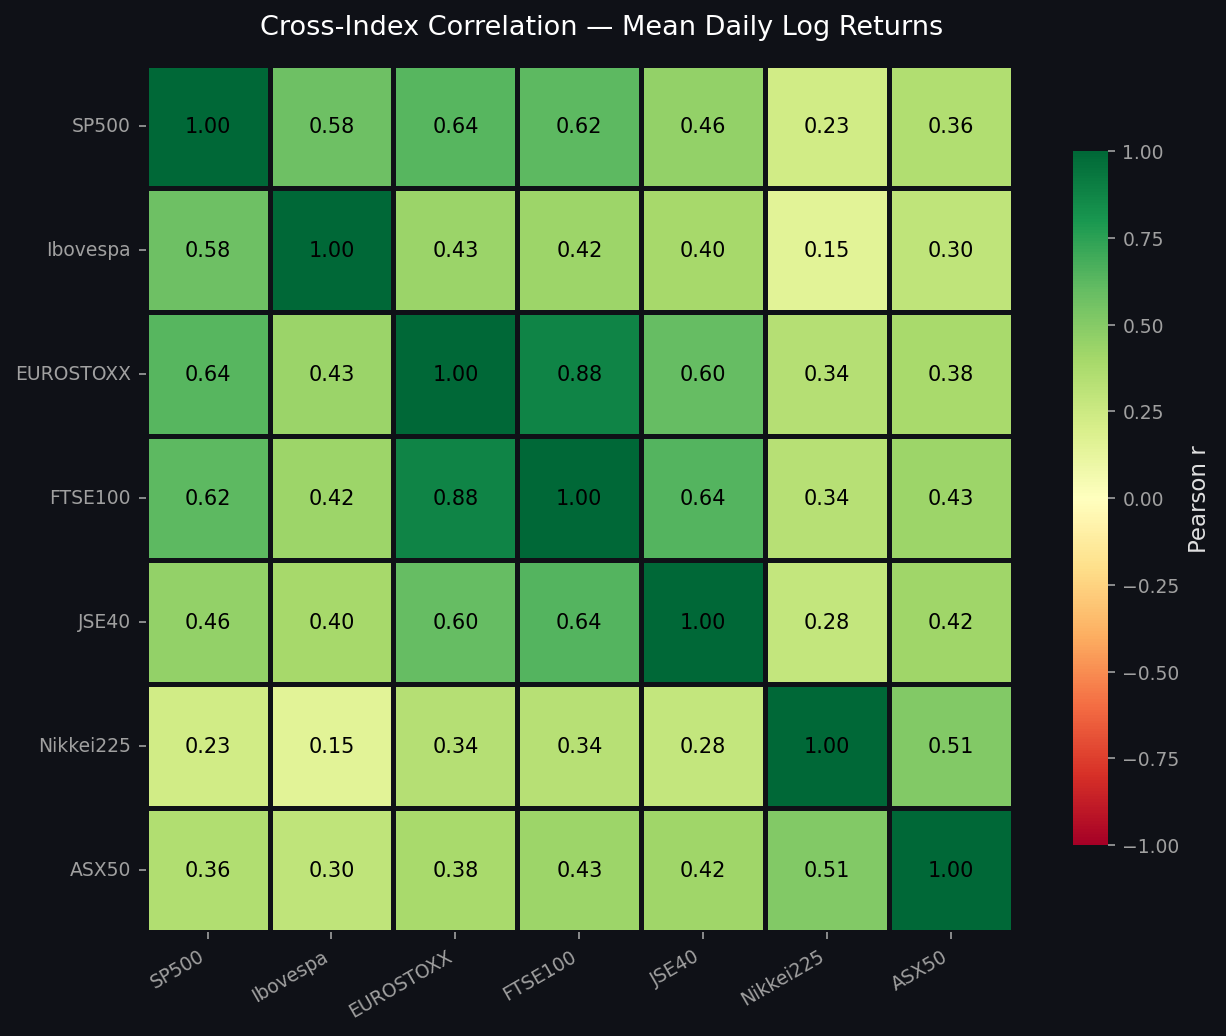

✅ Cross-index correlation saved.


In [ ]:
# Build a DataFrame of mean daily log-returns per index
index_returns = pd.DataFrame()
for name, df in index_data.items():
    lr = np.log(df / df.shift(1)).dropna().mean(axis=1)
    index_returns[name] = lr

index_returns = index_returns.dropna()
cross_corr = index_returns.corr()

fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle('Cross-Index Correlation — Mean Daily Log Returns', color='white', fontsize=13)

sns.heatmap(
    cross_corr, ax=ax,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 10, 'color': 'black'},
    linewidths=1.5, linecolor='#0f1117',
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cross_index_correlation.png', bbox_inches='tight')
plt.show()
print('✅ Cross-index correlation saved.')

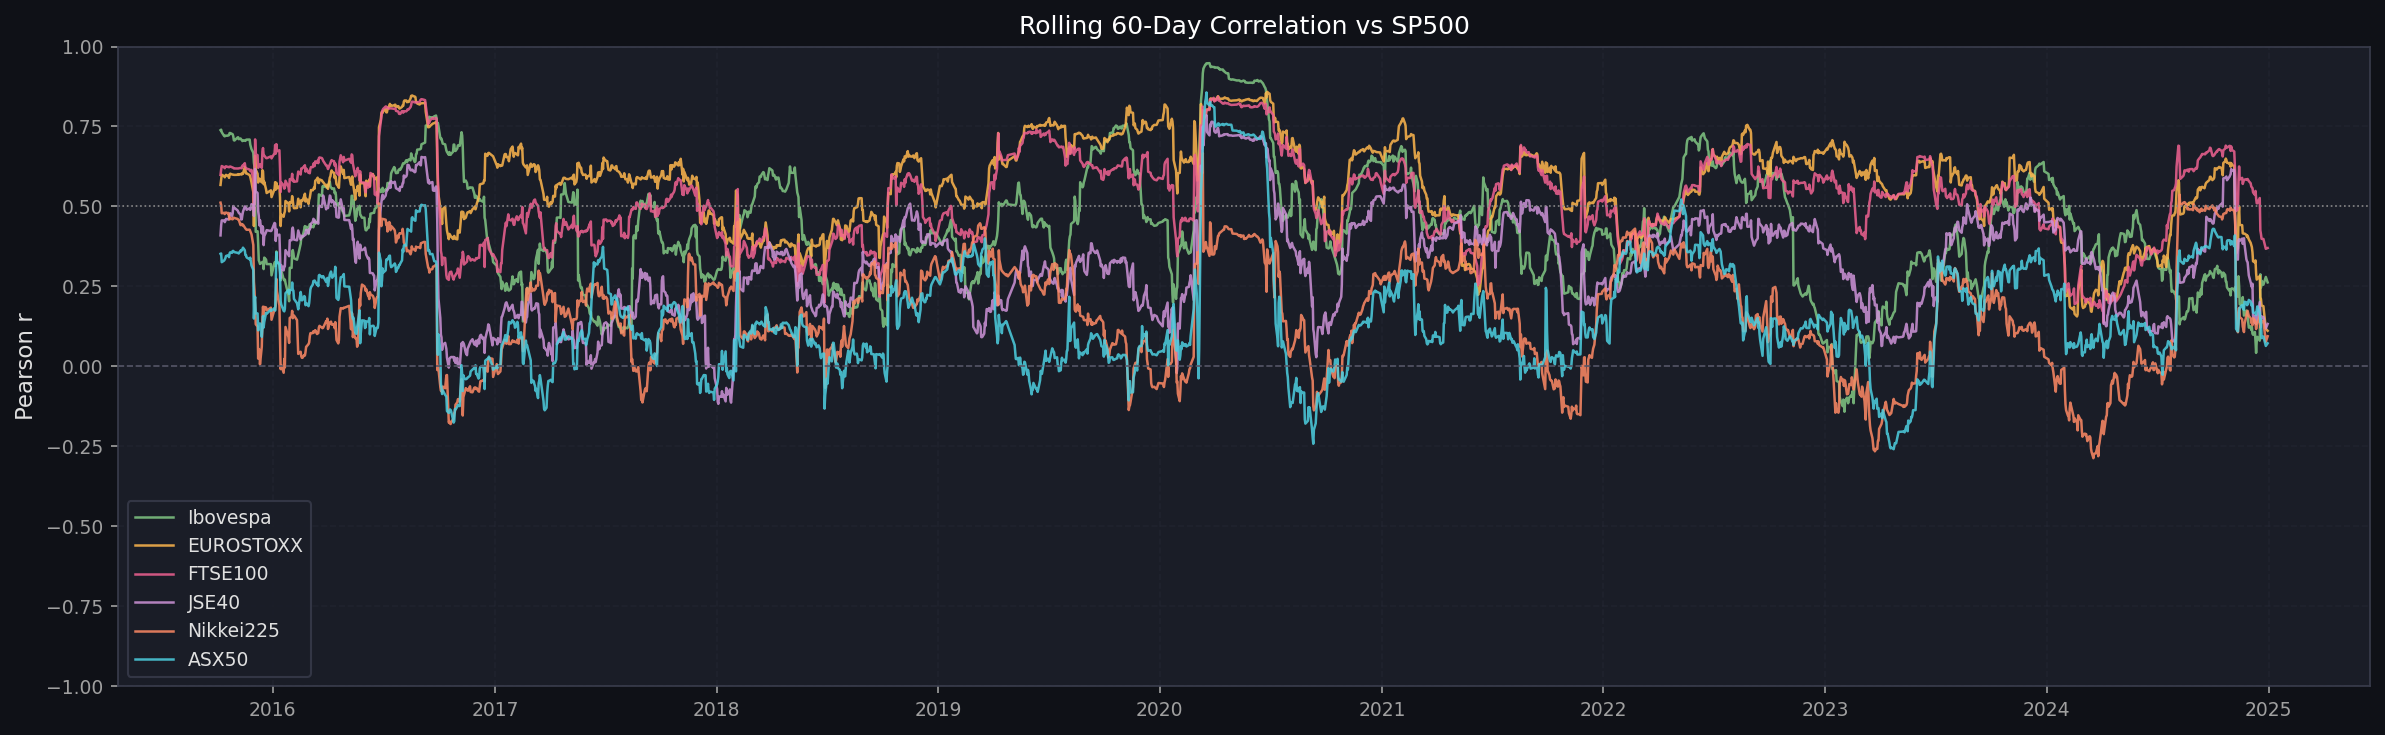

✅ Rolling correlation saved.


In [ ]:
# @title
ROLL_WINDOW = 60  # trading days

# Compute rolling correlation for each pair against SP500 (if present)
if 'SP500' in index_returns.columns:
    base_col = 'SP500'
else:
    base_col = index_returns.columns[0]

fig, ax = plt.subplots(figsize=(16, 5))
ax.set_title(f'Rolling {ROLL_WINDOW}-Day Correlation vs {base_col}', color='white', fontsize=12)

for name in index_returns.columns:
    if name == base_col:
        continue
    rolling_corr = index_returns[name].rolling(ROLL_WINDOW).corr(index_returns[base_col])
    color = INDEX_COLORS.get(name, '#ffffff')
    ax.plot(rolling_corr, label=name, color=color, linewidth=1.2, alpha=0.85)

ax.axhline(0, color='#555566', linestyle='--', linewidth=0.8)
ax.axhline(0.5, color='#888', linestyle=':', linewidth=0.8)
ax.set_ylabel('Pearson r')
ax.set_ylim(-1, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('rolling_correlation.png', bbox_inches='tight')
plt.show()
print('✅ Rolling correlation saved.')

CORRELATION PLOT

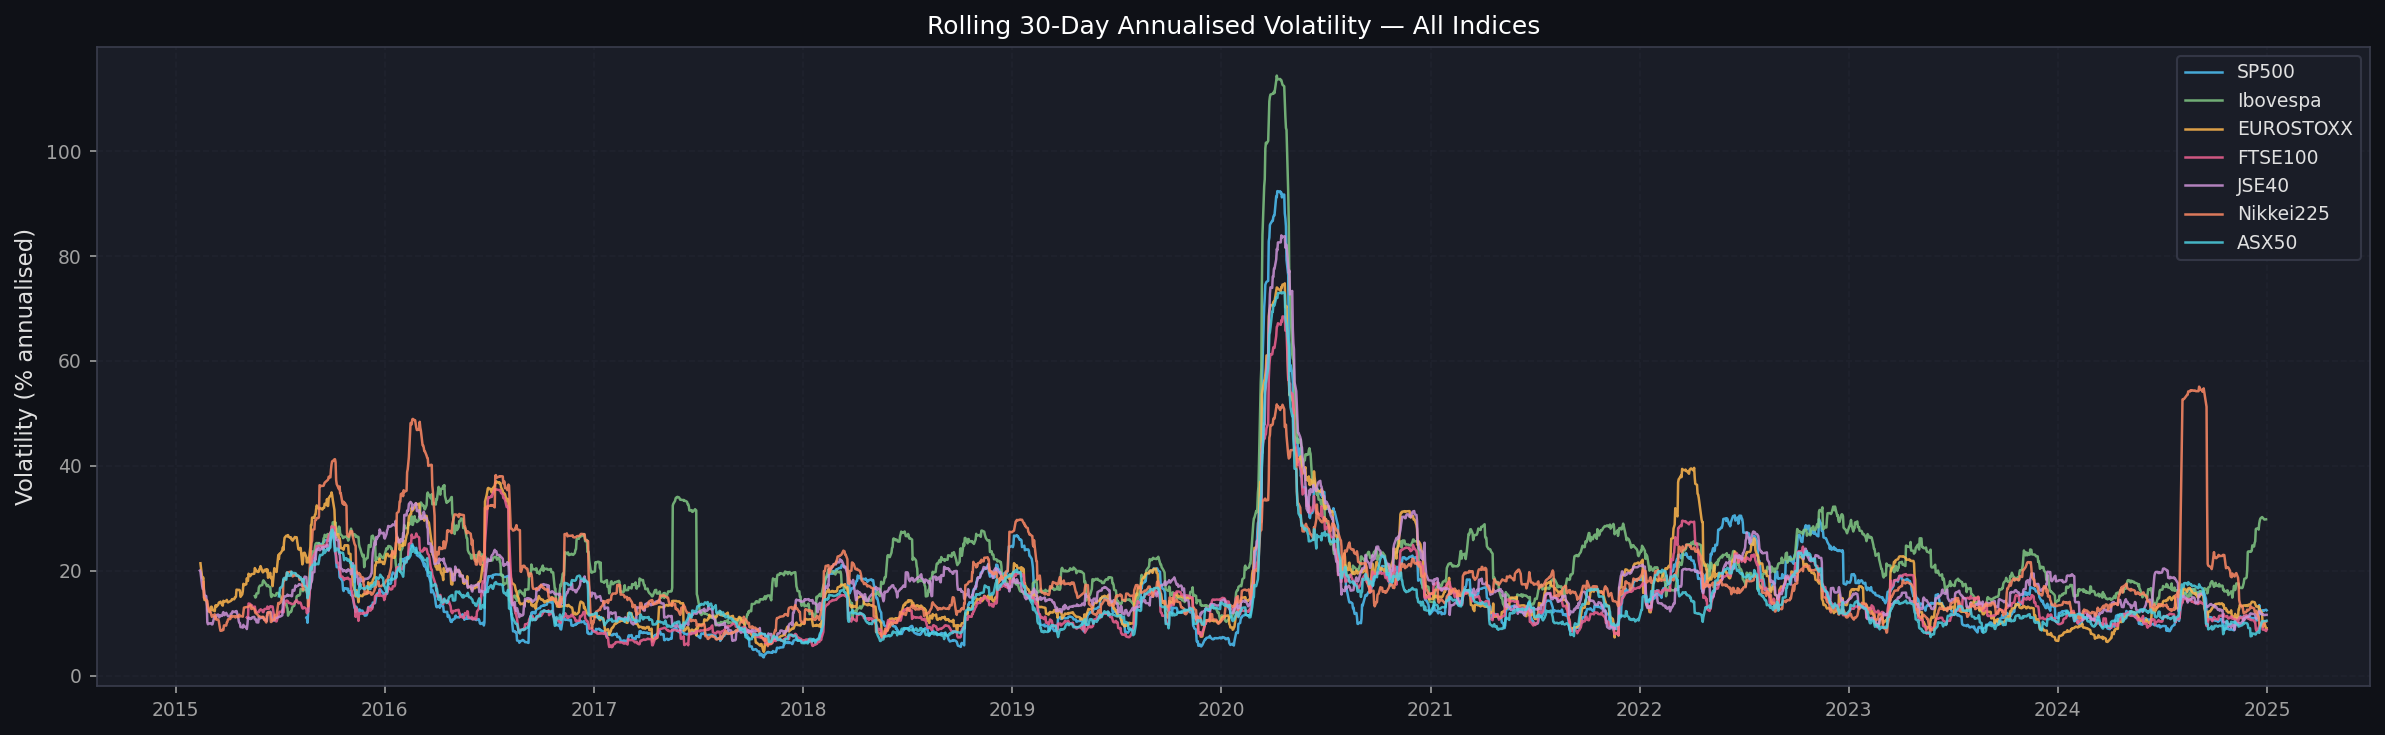

✅ Rolling volatility saved.


In [ ]:
# @title
fig, ax = plt.subplots(figsize=(16, 5))
ax.set_title('Rolling 30-Day Annualised Volatility — All Indices', fontsize=12, color='white')

for name, df in index_data.items():
    color = INDEX_COLORS.get(name, '#ffffff')
    log_ret = np.log(df / df.shift(1)).dropna()
    mean_ret = log_ret.mean(axis=1)
    rolling_vol = mean_ret.rolling(30).std() * np.sqrt(252) * 100  # annualised %
    ax.plot(rolling_vol, label=name, color=color, linewidth=1.2, alpha=0.85)

ax.set_ylabel('Volatility (% annualised)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('rolling_volatility.png', bbox_inches='tight')
plt.show()
print('✅ Rolling volatility saved.')

In [ ]:
# @title
print('=' * 65)
print('  EDA SUMMARY — Isaac')
print('=' * 65)
print(f'  Time Horizon    : 10 years ({FULL_START} → {FULL_END})')
print(f'  Test Window     : {TEST_START} → {TEST_END}')
print(f'  Indices covered : {len(index_data)}')
total_tickers = sum(df.shape[1] for df in index_data.values())
print(f'  Total tickers   : {total_tickers}')
print()
print('  Splits implemented:')
print('    • 80:20 (same start date)')
print('    • 70:30 (same start date)')
print('    • 80:10:10 (same start date)')
print('    • TimeSeriesSplit k=5 (Cross-Fold Validation)')
print('    • CPCV n=6 groups, k=2 test, purge=5d, embargo=5d')
print()
print('  Normalisation strategies: Min-Max, Z-Score, Base-100')
print()
print('  Charts generated:')
charts = [
    'split_visualisation.png',
    'tss_crossfold.png',
    'cpcv_paths.png',
    'price_charts_base100.png',
    'return_distributions.png',
    'cross_index_correlation.png',
    'rolling_correlation.png',
    'rolling_volatility.png',
]
for c in charts:
    print(f'    ✅  {c}')
print('=' * 65)

  EDA SUMMARY — Isaac
  Time Horizon    : 10 years (2015-01-01 → 2025-12-31)
  Test Window     : 2026-01-01 → 2026-03-30
  Indices covered : 7
  Total tickers   : 953

  Splits implemented:
    • 80:20 (same start date)
    • 70:30 (same start date)
    • 80:10:10 (same start date)
    • TimeSeriesSplit k=5 (Cross-Fold Validation)
    • CPCV n=6 groups, k=2 test, purge=5d, embargo=5d

  Normalisation strategies: Min-Max, Z-Score, Base-100

  Charts generated:
    ✅  split_visualisation.png
    ✅  tss_crossfold.png
    ✅  cpcv_paths.png
    ✅  price_charts_base100.png
    ✅  return_distributions.png
    ✅  cross_index_correlation.png
    ✅  rolling_correlation.png
    ✅  rolling_volatility.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

WINDOWS = [1, 2, 3, 4, 5, 7, 14, 21, 28]

def compute_index_mean_returns(df):
    lr = np.log(df / df.shift(1))
    return lr.mean(axis=1).dropna()

def compute_portfolio_return(index_data_dict):
    idx_returns = pd.DataFrame({
        name: compute_index_mean_returns(df)
        for name, df in index_data_dict.items()
    })
    idx_returns = idx_returns.dropna()
    portfolio = idx_returns.mean(axis=1)
    return idx_returns, portfolio

def make_macro_factor_series(macro_df):
    macro = macro_df.copy()

    rename_map = {}
    for c in macro.columns:
        if 'VIX' in c.upper():
            rename_map[c] = 'VIX'
        elif 'GOLD' in c.upper():
            rename_map[c] = 'Gold'
        elif 'OIL' in c.upper() or 'CRUDE' in c.upper():
            rename_map[c] = 'Oil'
        elif 'BITCOIN' in c.upper():
            rename_map[c] = 'Bitcoin'
        elif 'EUR' in c.upper():
            rename_map[c] = 'EURUSD'
        elif 'JPY' in c.upper():
            rename_map[c] = 'JPYUSD'
        elif 'YIELD' in c.upper():
            rename_map[c] = c

    macro = macro.rename(columns=rename_map)

    cols = [c for c in ['VIX', 'Gold', 'Oil', 'Bitcoin', 'EURUSD', 'JPYUSD'] if c in macro.columns]
    if len(cols) == 0:
        return None

    macro_subset = macro[cols].copy()
    macro_lr = np.log(macro_subset / macro_subset.shift(1)).replace([np.inf, -np.inf], np.nan)
    macro_factor = macro_lr.mean(axis=1).dropna()
    return macro_factor

def rolling_corr_multiwindow(target, reference, windows=WINDOWS):
    out = pd.DataFrame(index=target.index)
    for w in windows:
        if w == 1:
            out[f'{w}D'] = pd.Series(1.0, index=target.index)
        else:
            out[f'{w}D'] = target.rolling(w).corr(reference)
    return out

def plot_rolling_corr_for_index(index_name, index_df, global_portfolio=None, macro_factor=None, out_dir='output'):
    idx_ret = compute_index_mean_returns(index_df)

    fig, axes = plt.subplots(3 if macro_factor is not None else 2, 1, figsize=(16, 10), sharex=True)
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    # 1) vs own benchmark line: index mean vs 1-day lagged return
    ref_self = idx_ret.shift(1).dropna()
    targ_self = idx_ret.loc[ref_self.index]
    corr_self = rolling_corr_multiwindow(targ_self, ref_self)

    ax = axes[0]
    for col in corr_self.columns:
        ax.plot(corr_self.index, corr_self[col], label=col, linewidth=1.2)
    ax.set_title(f'{index_name} — Rolling Correlation vs 1-Day Lag', fontsize=12)
    ax.set_ylabel('Corr')
    ax.legend(ncol=4, fontsize=8)
    ax.grid(True, alpha=0.3)

    # 2) vs global portfolio
    if global_portfolio is not None:
        common = idx_ret.index.intersection(global_portfolio.index)
        targ = idx_ret.loc[common]
        ref = global_portfolio.loc[common]
        corr_global = rolling_corr_multiwindow(targ, ref)

        ax = axes[1]
        for col in corr_global.columns:
            ax.plot(corr_global.index, corr_global[col], label=col, linewidth=1.2)
        ax.set_title(f'{index_name} — Rolling Correlation vs Global Portfolio', fontsize=12)
        ax.set_ylabel('Corr')
        ax.legend(ncol=4, fontsize=8)
        ax.grid(True, alpha=0.3)

    # 3) vs macro factor
    if macro_factor is not None:
        common = idx_ret.index.intersection(macro_factor.index)
        targ = idx_ret.loc[common]
        ref = macro_factor.loc[common]
        corr_macro = rolling_corr_multiwindow(targ, ref)

        ax = axes[-1]
        for col in corr_macro.columns:
            ax.plot(corr_macro.index, corr_macro[col], label=col, linewidth=1.2)
        ax.set_title(f'{index_name} — Rolling Correlation vs Macro Factor', fontsize=12)
        ax.set_ylabel('Corr')
        ax.legend(ncol=4, fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()

    fname = f'{out_dir}/rolling_corr_{index_name.lower()}.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    return fname

# Build global portfolio and macro factor
index_returns_df, global_portfolio = compute_portfolio_return(index_data)
macro_factor = make_macro_factor_series(macro_data) if macro_data is not None else None

# Generate plots for each index
saved_files = []
for name, df in index_data.items():
    saved = plot_rolling_corr_for_index(
        index_name=name,
        index_df=df,
        global_portfolio=global_portfolio,
        macro_factor=macro_factor,
        out_dir='.'
    )
    saved_files.append(saved)

print("Saved plots:")
for f in saved_files:
    print(f)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

WINDOWS = [2, 3, 4, 5, 7, 14, 21, 28]   # use 2+; 1-day is not valid for correlation

def safe_logdet_corr(corr_matrix, eps=1e-10):
    """
    Compute log(det(C)) for a correlation matrix C.
    Uses eigenvalues for numerical stability.
    """
    C = corr_matrix.values.astype(float)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)

    # Symmetrize and stabilize
    C = (C + C.T) / 2.0
    np.fill_diagonal(C, 1.0)
    C = C + np.eye(C.shape[0]) * eps

    eigvals = np.linalg.eigvalsh(C)
    eigvals = np.clip(eigvals, eps, None)
    return float(np.sum(np.log(eigvals)))

def rolling_logdet_from_prices(price_df, windows=WINDOWS, min_periods=None):
    """
    Returns a DataFrame with one column per window:
    rolling log-determinant of the correlation matrix of log returns.
    """
    ret = np.log(price_df / price_df.shift(1)).replace([np.inf, -np.inf], np.nan).dropna(how='all')

    out = pd.DataFrame(index=ret.index)

    for w in windows:
        mp = min_periods if min_periods is not None else w
        vals = []

        for i in range(len(ret)):
            if i + 1 < mp:
                vals.append(np.nan)
                continue

            window_slice = ret.iloc[i - w + 1:i + 1].dropna(axis=1, how='any')

            if window_slice.shape[0] < w or window_slice.shape[1] < 2:
                vals.append(np.nan)
                continue

            corr = window_slice.corr()

            # Need at least 2 assets and a finite determinant
            if corr.shape[0] < 2 or corr.isna().values.any():
                vals.append(np.nan)
                continue

            try:
                vals.append(safe_logdet_corr(corr))
            except Exception:
                vals.append(np.nan)

        out[f'{w}D'] = vals

    return out

def plot_index_logdet(index_name, price_df, windows=WINDOWS, out_dir='.'):
    series_df = rolling_logdet_from_prices(price_df, windows=windows)

    fig, ax = plt.subplots(figsize=(16, 6))
    for col in series_df.columns:
        ax.plot(series_df.index, series_df[col], linewidth=1.3, label=col)

    ax.set_title(f'{index_name} — Rolling Log-Determinant of Correlation Matrix', fontsize=13)
    ax.set_ylabel('log(det(C))')
    ax.set_xlabel('Date')
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=4, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    fname = f'{out_dir}/logdet_corr_{index_name.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    return series_df, fname

# Generate for each index
logdet_results = {}
saved_files = []

for name, df in index_data.items():
    res, fname = plot_index_logdet(name, df, windows=WINDOWS, out_dir='.')
    logdet_results[name] = res
    saved_files.append(fname)

print("Saved files:")
for f in saved_files:
    print(f)